In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/eye-raw/Eyelid/266.jpeg
/kaggle/input/eye-raw/Eyelid/228.jpeg
/kaggle/input/eye-raw/Eyelid/761.jpeg
/kaggle/input/eye-raw/Eyelid/833.jpeg
/kaggle/input/eye-raw/Eyelid/130.jpeg
/kaggle/input/eye-raw/Eyelid/158.jpeg
/kaggle/input/eye-raw/Eyelid/977.jpeg
/kaggle/input/eye-raw/Eyelid/aug_990.jpg
/kaggle/input/eye-raw/Eyelid/381.jpeg
/kaggle/input/eye-raw/Eyelid/335.jpeg
/kaggle/input/eye-raw/Eyelid/aug_986.jpg
/kaggle/input/eye-raw/Eyelid/265.jpeg
/kaggle/input/eye-raw/Eyelid/843.jpeg
/kaggle/input/eye-raw/Eyelid/aug_962.jpg
/kaggle/input/eye-raw/Eyelid/aug_894.jpg
/kaggle/input/eye-raw/Eyelid/251.jpeg
/kaggle/input/eye-raw/Eyelid/aug_896.jpg
/kaggle/input/eye-raw/Eyelid/399.jpeg
/kaggle/input/eye-raw/Eyelid/992.jpeg
/kaggle/input/eye-raw/Eyelid/252.jpeg
/kaggle/input/eye-raw/Eyelid/155.jpeg
/kaggle/input/eye-raw/Eyelid/626.jpeg
/kaggle/input/eye-raw/Eyelid/152.jpeg
/kaggle/input/eye-raw/Eyelid/389.jpeg
/kaggle/input/eye-raw/Eyelid/462.jpeg
/kaggle/input/eye-raw/Eyelid/676.jp

In [4]:
# Code Block 0: Imports & device setup 

import os
import shutil
import random
from pathlib import Path

import numpy as np
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import classification_report, confusion_matrix
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

classes = ["Cataract", "Conjunctivitis", "Eyelid", "Normal", "Uveitis"]
num_classes = len(classes)



Using device: cuda


In [5]:
import os
print("Inside /kaggle/input:", os.listdir("/kaggle/input"))


Inside /kaggle/input: ['eye-raw']


In [6]:
print(os.listdir("/kaggle/input/eye-raw"))


['Eyelid', 'Normal', 'Cataract', 'Uveitis', 'Conjunctivitis']


In [7]:
# ==============================
# Class labels (explicit & fixed)
# ==============================
classes = [
    "Cataract",
    "Conjunctivitis",
    "Eyelid",
    "Normal",
    "Uveitis"
]


In [8]:
import os

KAGGLE_INPUT = "/kaggle/input"
DATASET_NAME = "eye-raw"

RAW_BASE_DIR = os.path.join(KAGGLE_INPUT, DATASET_NAME)

print("Inside /kaggle/input:", os.listdir(KAGGLE_INPUT))

assert os.path.exists(RAW_BASE_DIR), "❌ Dataset folder not found!"
assert all(
    os.path.isdir(os.path.join(RAW_BASE_DIR, c)) for c in classes
), "❌ Class folders missing!"

print("✅ Dataset root confirmed:", RAW_BASE_DIR)
print("Classes found:", os.listdir(RAW_BASE_DIR))


Inside /kaggle/input: ['eye-raw']
✅ Dataset root confirmed: /kaggle/input/eye-raw
Classes found: ['Eyelid', 'Normal', 'Cataract', 'Uveitis', 'Conjunctivitis']


In [9]:
#  Code Block 2: Sanity checks on raw dataset 

if RAW_BASE_DIR is None:
    raise ValueError("RAW_BASE_DIR is None. Please set it manually to your dataset root.")

print("Checking class folders inside:", RAW_BASE_DIR)

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

total_images = 0
for cls in classes:
    class_path = os.path.join(RAW_BASE_DIR, cls)
    exists = os.path.isdir(class_path)
    print(f"\nClass: {cls}")
    print("  Path:", class_path)
    print("  Exists:", exists)

    if exists:
        files = [f for f in os.listdir(class_path) if f.lower().endswith(image_exts)]
        num_files = len(files)
        total_images += num_files
        print(f"  Number of image files: {num_files}")
    else:
        print("WARNING: This class folder was NOT found.")

print("\n=== RAW DATA SUMMARY ===")
print("Total classes expected:", len(classes))
print("Total images found across all existing class folders:", total_images)


Checking class folders inside: /kaggle/input/eye-raw

Class: Cataract
  Path: /kaggle/input/eye-raw/Cataract
  Exists: True
  Number of image files: 544

Class: Conjunctivitis
  Path: /kaggle/input/eye-raw/Conjunctivitis
  Exists: True
  Number of image files: 357

Class: Eyelid
  Path: /kaggle/input/eye-raw/Eyelid
  Exists: True
  Number of image files: 525

Class: Normal
  Path: /kaggle/input/eye-raw/Normal
  Exists: True
  Number of image files: 649

Class: Uveitis
  Path: /kaggle/input/eye-raw/Uveitis
  Exists: True
  Number of image files: 223

=== RAW DATA SUMMARY ===
Total classes expected: 5
Total images found across all existing class folders: 2298


In [11]:
import os
import pandas as pd

# ----- REQUIRED: set these -----
# RAW_BASE_DIR = "/content/eye-raw"   # Colab example
# classes = ["Cataract","Conjunctivitis","Eyelid","Normal","Uveitis"]

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

rows = []
total_images = 0

for cls in classes:
    class_path = os.path.join(RAW_BASE_DIR, cls)
    if not os.path.isdir(class_path):
        rows.append({"Class": cls, "Images": 0, "Status": "Missing folder"})
        continue

    files = [f for f in os.listdir(class_path) if f.lower().endswith(image_exts)]
    count = len(files)
    total_images += count
    rows.append({"Class": cls, "Images": count, "Status": "OK"})

df_dataset = pd.DataFrame(rows)
df_dataset.loc[len(df_dataset)] = {"Class": "TOTAL", "Images": total_images, "Status": ""}

print("=== DATASET SUMMARY (RAW) ===")
display(df_dataset)


=== DATASET SUMMARY (RAW) ===


,Class,Images,Status
0,Cataract,544,OK
1,Conjunctivitis,357,OK
2,Eyelid,525,OK
3,Normal,649,OK
4,Uveitis,223,OK
5,TOTAL,2298,


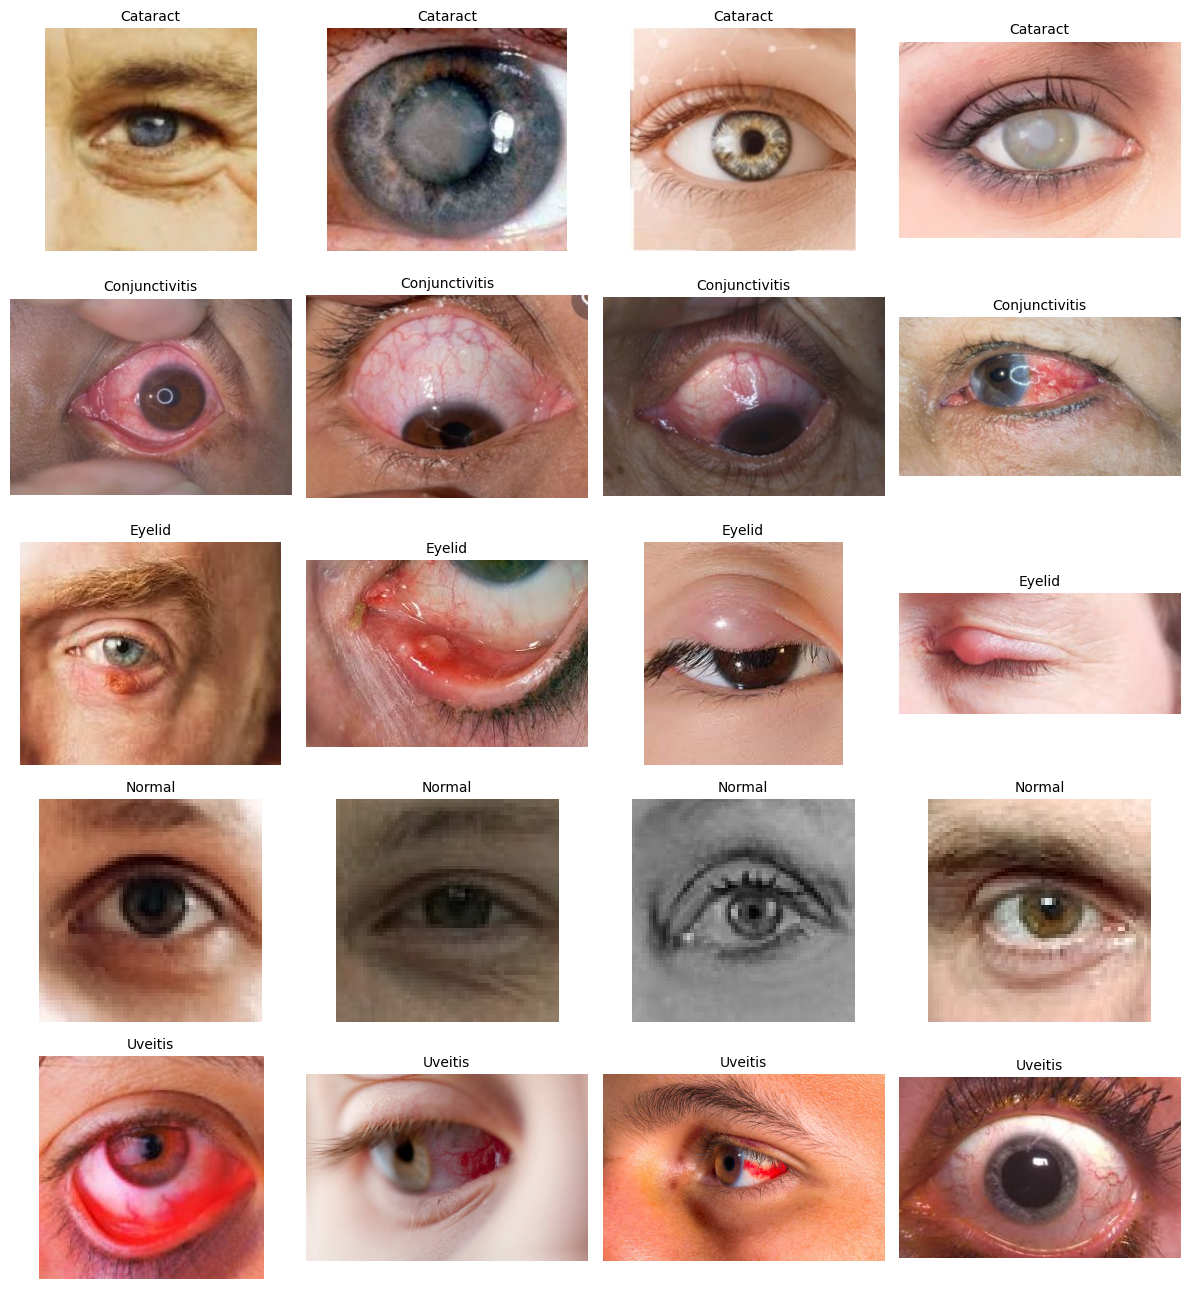

In [12]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def sample_grid_per_class(raw_base_dir, classes, samples_per_class=4, seed=42):
    random.seed(seed)
    image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

    nrows = len(classes)
    ncols = samples_per_class

    plt.figure(figsize=(3*ncols, 2.6*nrows))

    plot_idx = 1
    for r, cls in enumerate(classes):
        class_path = os.path.join(raw_base_dir, cls)
        files = [f for f in os.listdir(class_path) if f.lower().endswith(image_exts)]
        if len(files) == 0:
            # If class folder empty/missing
            for _ in range(ncols):
                ax = plt.subplot(nrows, ncols, plot_idx)
                ax.axis("off")
                ax.set_title(f"{cls}\n(no images)", fontsize=10)
                plot_idx += 1
            continue

        chosen = random.sample(files, k=min(samples_per_class, len(files)))

        for c in range(ncols):
            ax = plt.subplot(nrows, ncols, plot_idx)
            ax.axis("off")

            if c < len(chosen):
                img_path = os.path.join(class_path, chosen[c])
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                ax.set_title(cls, fontsize=10)
            else:
                ax.set_title(cls, fontsize=10)

            plot_idx += 1

    plt.tight_layout()
    plt.show()

# Run sample grid
sample_grid_per_class(RAW_BASE_DIR, classes, samples_per_class=4, seed=42)


In [10]:
#Code Block 3: Preprocessing helper function

PREPROC_DIR = "/kaggle/working/eye_preprocessed"
os.makedirs(PREPROC_DIR, exist_ok=True)

TARGET_SIZE = (224, 224)

def preprocess_image(img_path):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, TARGET_SIZE)

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray_clahe = clahe.apply(gray)

    gray_filtered = cv2.GaussianBlur(gray_clahe, (3,3), 0)

    processed_rgb = cv2.merge([gray_filtered]*3)
    return img_rgb, processed_rgb

psnr_vals = []
ssim_vals = []
counter = 0

for cls in classes:
    in_dir = os.path.join(RAW_BASE_DIR, cls)
    out_dir = os.path.join(PREPROC_DIR, cls)
    os.makedirs(out_dir, exist_ok=True)

    files = [f for f in os.listdir(in_dir)]
    print(f"Preprocessing {cls}: {len(files)} images")

    for f in files:
        orig, proc = preprocess_image(os.path.join(in_dir, f))
        if orig is None:
            continue

        out_name = f.split('.')[0] + ".png"
        Image.fromarray(proc).save(os.path.join(out_dir, out_name))

        if counter < 200:
            g1 = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)
            g2 = cv2.cvtColor(proc, cv2.COLOR_RGB2GRAY)
            psnr_vals.append(psnr(g1, g2, data_range=255))
            ssim_vals.append(ssim(g1, g2, data_range=255))
            counter += 1

print("Avg PSNR:", np.mean(psnr_vals))
print("Avg SSIM:", np.mean(ssim_vals))

Preprocessing Cataract: 544 images
Preprocessing Conjunctivitis: 357 images
Preprocessing Eyelid: 525 images
Preprocessing Normal: 649 images
Preprocessing Uveitis: 223 images
Avg PSNR: 21.395502208895813
Avg SSIM: 0.8529433763921915


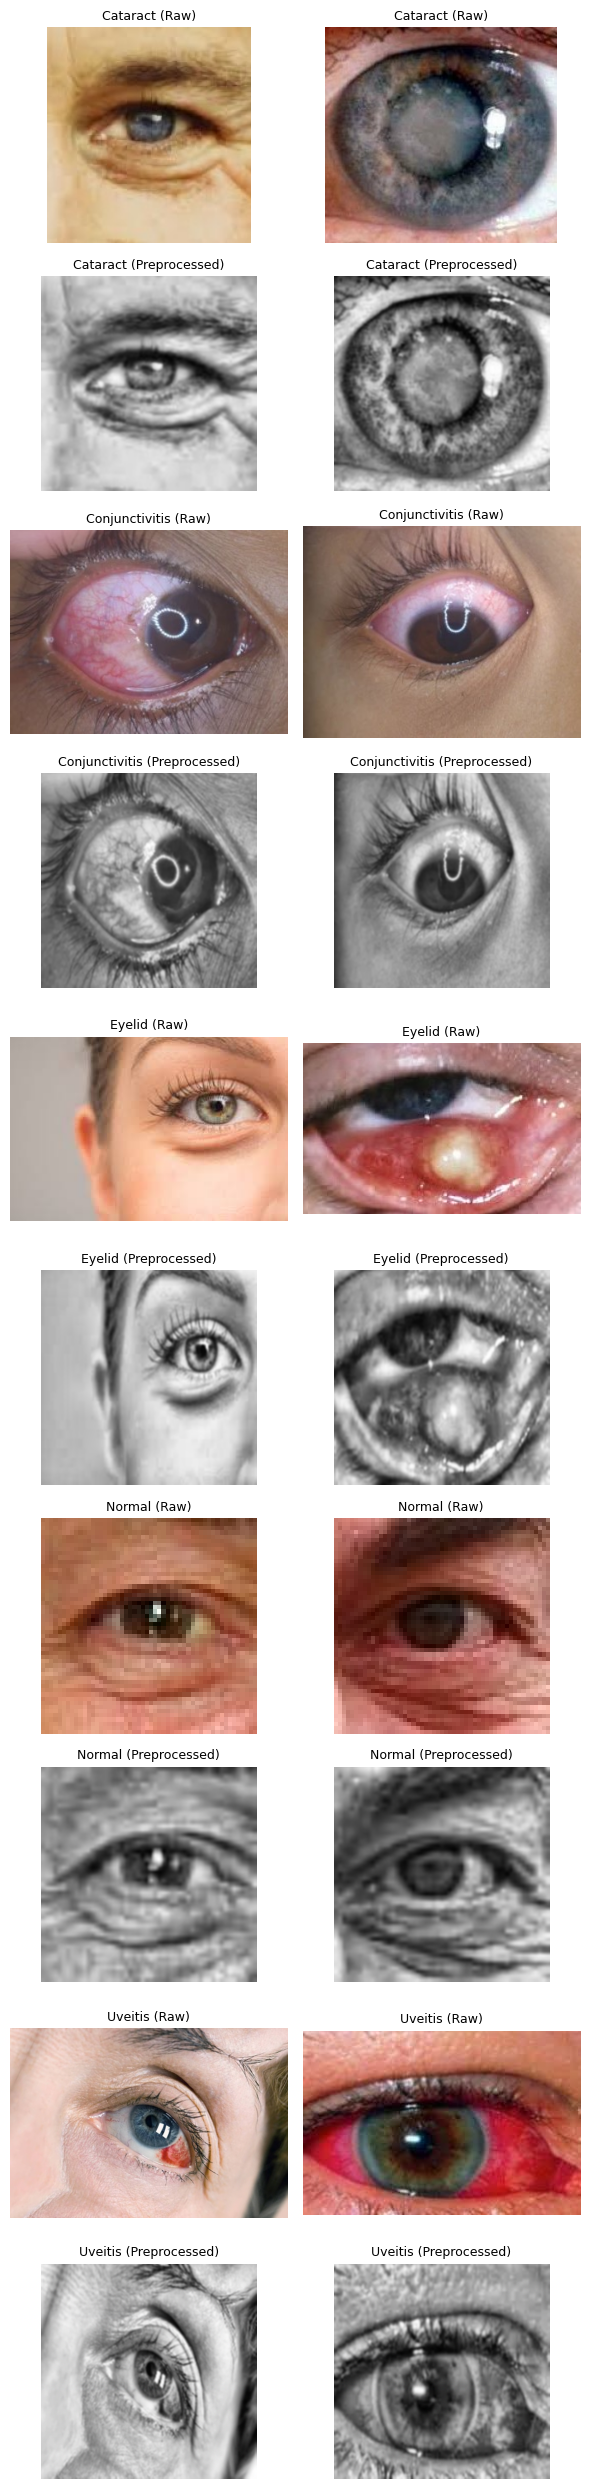

In [13]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_before_after(raw_dir, proc_dir, classes, samples_per_class=2, seed=42):
    random.seed(seed)

    image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    rows = len(classes) * 2
    cols = samples_per_class

    plt.figure(figsize=(3*cols, 2.5*rows))
    plot_idx = 1

    for cls in classes:
        raw_cls_dir = os.path.join(raw_dir, cls)
        proc_cls_dir = os.path.join(proc_dir, cls)

        files = [f for f in os.listdir(raw_cls_dir) if f.lower().endswith(image_exts)]
        if len(files) == 0:
            continue

        chosen = random.sample(files, min(samples_per_class, len(files)))

        # ---- Original images ----
        for f in chosen:
            img = Image.open(os.path.join(raw_cls_dir, f)).convert("RGB")
            ax = plt.subplot(rows, cols, plot_idx)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{cls} (Raw)", fontsize=9)
            plot_idx += 1

        # ---- Preprocessed images ----
        for f in chosen:
            fname = f.split(".")[0] + ".png"
            proc_img = Image.open(os.path.join(proc_cls_dir, fname)).convert("RGB")
            ax = plt.subplot(rows, cols, plot_idx)
            ax.imshow(proc_img)
            ax.axis("off")
            ax.set_title(f"{cls} (Preprocessed)", fontsize=9)
            plot_idx += 1

    plt.tight_layout()
    plt.show()


# Run visualization
plot_before_after(RAW_BASE_DIR, PREPROC_DIR, classes, samples_per_class=2)


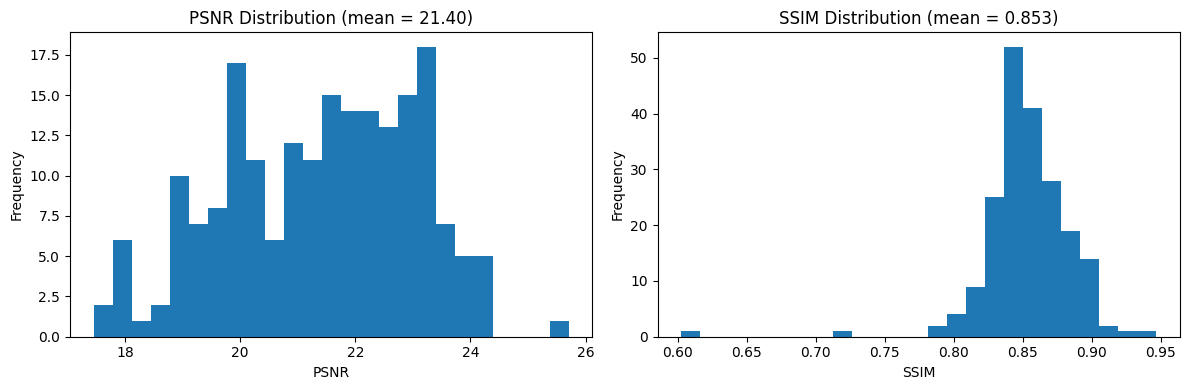

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,4))

# ---- PSNR ----
plt.subplot(1,2,1)
plt.hist(psnr_vals, bins=25)
plt.xlabel("PSNR")
plt.ylabel("Frequency")
plt.title(f"PSNR Distribution (mean = {np.mean(psnr_vals):.2f})")

# ---- SSIM ----
plt.subplot(1,2,2)
plt.hist(ssim_vals, bins=25)
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.title(f"SSIM Distribution (mean = {np.mean(ssim_vals):.3f})")

plt.tight_layout()
plt.show()


In [6]:
SPLIT_DIR = "/kaggle/working/eye_splits"

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
os.makedirs(SPLIT_DIR, exist_ok=True)

for folder in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_DIR, folder, cls), exist_ok=True)

for cls in classes:
    src = os.path.join(PREPROC_DIR, cls)
    files = [f for f in os.listdir(src) if f.endswith(".png")]

    random.shuffle(files)

    n = len(files)
    n_train = int(0.8*n)
    n_val   = int(0.1*n)

    train_files = files[:n_train]
    val_files   = files[n_train:n_train+n_val]
    test_files  = files[n_train+n_val:]

    for f in train_files:
        shutil.copy(os.path.join(src,f), os.path.join(SPLIT_DIR,"train",cls,f))
    for f in val_files:
        shutil.copy(os.path.join(src,f), os.path.join(SPLIT_DIR,"val",cls,f))
    for f in test_files:
        shutil.copy(os.path.join(src,f), os.path.join(SPLIT_DIR,"test",cls,f))

    print(cls, ":", len(train_files), "train |", len(val_files), "val |", len(test_files), "test")


Cataract : 435 train | 54 val | 55 test
Conjunctivitis : 285 train | 35 val | 37 test
Eyelid : 420 train | 52 val | 53 test
Normal : 519 train | 64 val | 66 test
Uveitis : 178 train | 22 val | 23 test


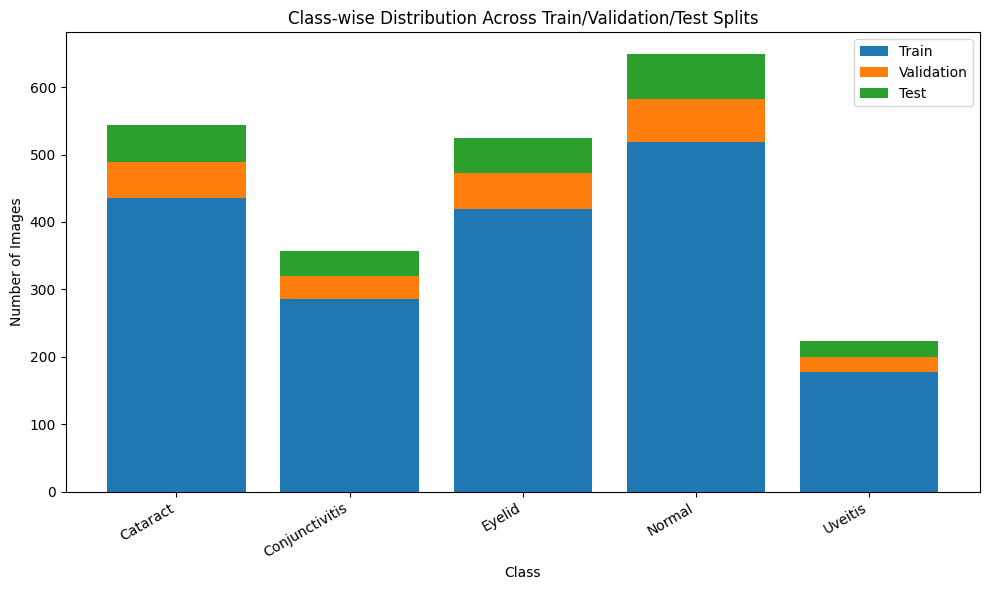

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Manual split counts from your output
classes = ["Cataract", "Conjunctivitis", "Eyelid", "Normal", "Uveitis"]
train = np.array([435, 285, 420, 519, 178])
val   = np.array([ 54,  35,  52,  64,  22])
test  = np.array([ 55,  37,  53,  66,  23])

x = np.arange(len(classes))

plt.figure(figsize=(10,6))

plt.bar(x, train, label="Train")
plt.bar(x, val,   bottom=train,        label="Validation")
plt.bar(x, test,  bottom=train+val,    label="Test")

plt.xticks(x, classes, rotation=30, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class-wise Distribution Across Train/Validation/Test Splits")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class EyeDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform
        self.samples = []
        for cls in classes:
            path = os.path.join(root, cls)
            if not os.path.isdir(path):
                print("Missing folder:", path)
                continue
            for f in os.listdir(path):
                if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff")):
                    self.samples.append((os.path.join(path,f), classes.index(cls)))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img = Image.open(fpath).convert("RGB")
        return self.transform(img), label

train_ds = EyeDataset(os.path.join(SPLIT_DIR, "train"), train_tf)
val_ds   = EyeDataset(os.path.join(SPLIT_DIR, "val"), test_tf)
test_ds  = EyeDataset(os.path.join(SPLIT_DIR, "test"), test_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print(len(train_ds), "train images")
print(len(val_ds), "val images")
print(len(test_ds), "test images")


1837 train images
227 val images
234 test images




1.ResNet18

In [8]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = 5  # Cataract, Conjunctivitis, Eyelid, Normal, Uveitis

def create_resnet18(num_classes=5):
    # Load pretrained ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace the final layer with Dropout + Linear
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_resnet18(num_classes).to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


In [ ]:
# Label smoothing helps generalization & calibration
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,    
    weight_decay=1e-4
)

# Reduced LR when val_loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    n_samples = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        # Gradient clipping to stabilize training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        n_samples += batch_size

    epoch_loss = running_loss / n_samples
    epoch_acc = running_corrects / n_samples
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    n_samples = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)
        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        n_samples += batch_size

    epoch_loss = running_loss / n_samples
    epoch_acc = running_corrects / n_samples
    return epoch_loss, epoch_acc


In [ ]:
num_epochs = 40
best_val_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # LR scheduler based on validation loss
    scheduler.step(val_loss)

    # Early stopping on best val_loss
    if val_loss < best_val_loss - 1e-4:  # small margin to avoid noise
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_resnet18.pth")
        print("Saved best model")
    else:
        patience_counter += 1
        print(f"  Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered")
        break




Epoch 1/40
  Train Loss: 0.8700, Acc: 0.7839
  Val   Loss: 0.6387, Acc: 0.8899
  ✔ Saved best model
Epoch 2/40
  Train Loss: 0.6276, Acc: 0.9004
  Val   Loss: 0.6629, Acc: 0.8943
  Patience: 1/5
Epoch 3/40
  Train Loss: 0.5768, Acc: 0.9309
  Val   Loss: 0.5880, Acc: 0.9251
  ✔ Saved best model
Epoch 4/40
  Train Loss: 0.5119, Acc: 0.9668
  Val   Loss: 0.5699, Acc: 0.9339
  ✔ Saved best model
Epoch 5/40
  Train Loss: 0.5011, Acc: 0.9690
  Val   Loss: 0.5295, Acc: 0.9471
  ✔ Saved best model
Epoch 6/40
  Train Loss: 0.5070, Acc: 0.9673
  Val   Loss: 0.5782, Acc: 0.9251
  Patience: 1/5
Epoch 7/40
  Train Loss: 0.4640, Acc: 0.9869
  Val   Loss: 0.4897, Acc: 0.9559
  ✔ Saved best model
Epoch 8/40
  Train Loss: 0.4546, Acc: 0.9907
  Val   Loss: 0.5085, Acc: 0.9471
  Patience: 1/5
Epoch 9/40
  Train Loss: 0.4482, Acc: 0.9924
  Val   Loss: 0.5521, Acc: 0.9251
  Patience: 2/5
Epoch 10/40
  Train Loss: 0.4390, Acc: 0.9946
  Val   Loss: 0.4877, Acc: 0.9559
  ✔ Saved best model
Epoch 11/40
  Train

In [ ]:
# Loaded best model
model.load_state_dict(torch.load("best_resnet18.pth", map_location=device))
model.to(device)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


Test Loss: 0.4511, Test Acc: 0.9744


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Epochs actually run (early stopping at 28)
epochs = np.arange(1, 29)

# ---- Train / Validation Loss ----
train_loss = [
    0.8700, 0.6276, 0.5768, 0.5119, 0.5011, 0.5070, 0.4640, 0.4546,
    0.4482, 0.4390, 0.4345, 0.4442, 0.4261, 0.4201, 0.4167, 0.4221,
    0.4178, 0.4100, 0.4090, 0.4090, 0.4076, 0.4066, 0.4051, 0.4041,
    0.4043, 0.4046, 0.4040, 0.4027
]

val_loss = [
    0.6387, 0.6629, 0.5880, 0.5699, 0.5295, 0.5782, 0.4897, 0.5085,
    0.5521, 0.4877, 0.4728, 0.5024, 0.4988, 0.4724, 0.4770, 0.4894,
    0.5186, 0.4676, 0.4680, 0.4802, 0.4615, 0.4733, 0.4606, 0.4749,
    0.4778, 0.4728, 0.4679, 0.4749
]

# ---- Train / Validation Accuracy ----
train_acc = [
    0.7839, 0.9004, 0.9309, 0.9668, 0.9690, 0.9673, 0.9869, 0.9907,
    0.9924, 0.9946, 0.9951, 0.9891, 0.9978, 0.9967, 0.9984, 0.9967,
    0.9995, 1.0000, 1.0000, 0.9989, 0.9995, 1.0000, 1.0000, 1.0000,
    1.0000, 1.0000, 1.0000, 1.0000
]

val_acc = [
    0.8899, 0.8943, 0.9251, 0.9339, 0.9471, 0.9251, 0.9559, 0.9471,
    0.9251, 0.9559, 0.9515, 0.9648, 0.9471, 0.9604, 0.9648, 0.9559,
    0.9515, 0.9648, 0.9604, 0.9604, 0.9604, 0.9648, 0.9604, 0.9559,
    0.9559, 0.9604, 0.9604, 0.9604
]


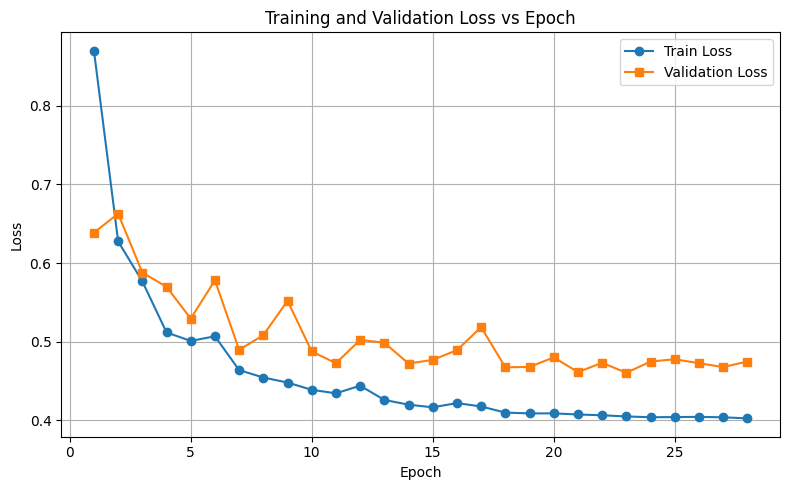

In [26]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker="o", label="Train Loss")
plt.plot(epochs, val_loss, marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


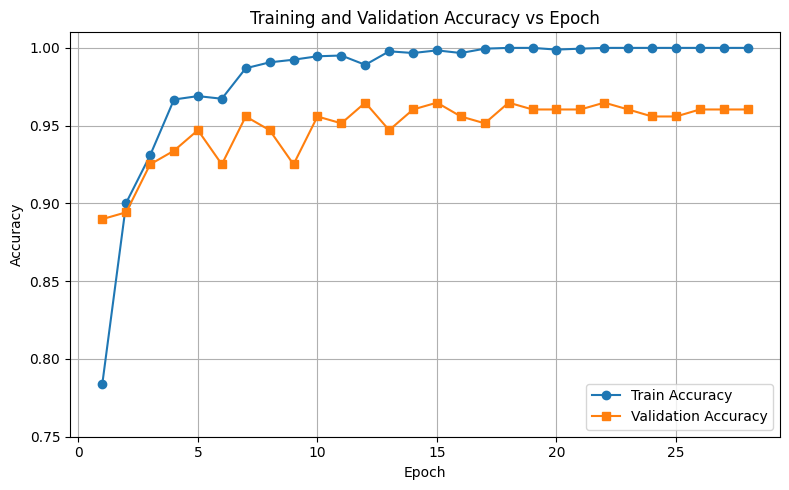

In [27]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, marker="o", label="Train Accuracy")
plt.plot(epochs, val_acc, marker="s", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.01)
plt.title("Training and Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

results_table = pd.DataFrame({
    "Split": ["Train (best)", "Validation (best)", "Test"],
    "Accuracy": [
        max(train_acc),
        max(val_acc),
        0.9744
    ],
    "Loss": [
        min(train_loss),
        min(val_loss),
        0.4511
    ]
})

display(results_table)


,Split,Accuracy,Loss
0,Train (best),1.0000,0.4027
1,Validation (best),0.9648,0.4606
2,Test,0.9744,0.4511


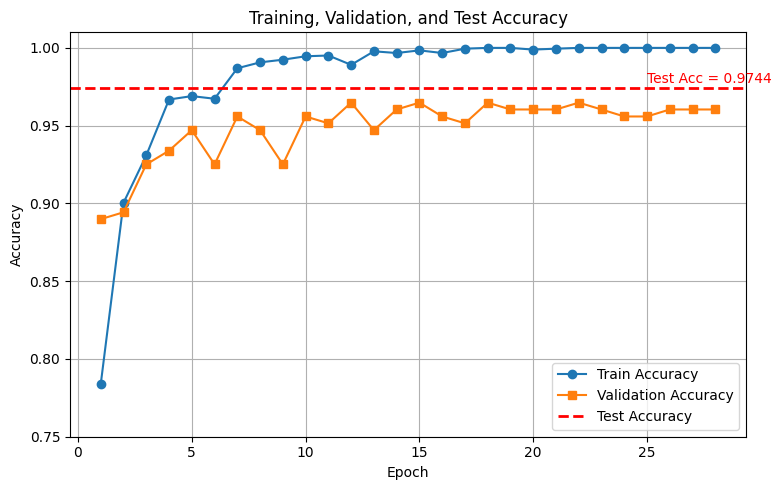

In [29]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc, marker="o", label="Train Accuracy")
plt.plot(epochs, val_acc, marker="s", label="Validation Accuracy")

# ---- Test accuracy annotation ----
test_acc = 0.9744
plt.axhline(y=test_acc, linestyle="--", color="red", linewidth=2, label="Test Accuracy")

plt.text(
    epochs[-1]-3, test_acc+0.003,
    f"Test Acc = {test_acc:.4f}",
    color="red", fontsize=10
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.01)
plt.title("Training, Validation, and Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Helper: evaluate a model and collect true + predicted labels
def get_preds_and_labels(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Helper: colorful confusion matrix
def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest", cmap="Oranges")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

ResNet18 Confusion Matrix (raw counts):
[[55  0  0  0  0]
 [ 0 36  1  0  0]
 [ 0  0 53  0  0]
 [ 0  0  0 66  0]
 [ 1  3  1  0 18]]


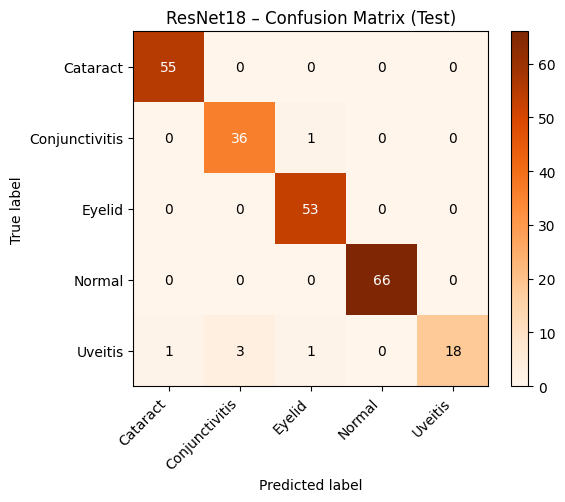

In [ ]:
#  ResNet18 colourful confusion matrix 

# 1. Rebuild the model and load best weights
resnet_best = create_resnet18(len(classes))
resnet_best.load_state_dict(torch.load("best_resnet18.pth", map_location=device))
resnet_best.to(device)

# 2. Get predictions on test set
y_true_res, y_pred_res = get_preds_and_labels(resnet_best, test_loader)

# 3. Build confusion matrix
cm_res = confusion_matrix(y_true_res, y_pred_res)
print("ResNet18 Confusion Matrix (raw counts):")
print(cm_res)

# 4. Plot colourful confusion matrix
plot_confusion_matrix(cm_res, classes, "ResNet18 – Confusion Matrix (Test)")


In [32]:
import pandas as pd

training_config = {
    "Model": "ResNet18 (ImageNet pretrained)",
    "Input Size": "224 × 224 × 3",
    "Number of Classes": 5,

    "Optimizer": "AdamW",
    "Learning Rate": "3e-4",
    "Weight Decay (L2)": "1e-4",

    "Loss Function": "CrossEntropyLoss",
    "Label Smoothing": "0.1",

    "Batch Size": 32,
    "Max Epochs": 40,
    "Early Stopping": "Yes (patience = 5)",

    "Scheduler": "ReduceLROnPlateau",
    "Scheduler Factor": "0.5",
    "Scheduler Patience": "2",

    "Gradient Clipping": "max_norm = 5.0",
    "Dropout": "0.5",

    "Framework": "PyTorch",
    "Device": "GPU" if torch.cuda.is_available() else "CPU"
}

df_config = pd.DataFrame(
    training_config.items(),
    columns=["Parameter", "Value"]
)

print("=== TRAINING CONFIGURATION ===")
display(df_config)


=== TRAINING CONFIGURATION ===


,Parameter,Value
0,Model,ResNet18 (ImageNet pretrained)
1,Input Size,224 × 224 × 3
2,Number of Classes,5
3,Optimizer,AdamW
4,Learning Rate,3e-4
5,Weight Decay (L2),1e-4
6,Loss Function,CrossEntropyLoss
7,Label Smoothing,0.1
8,Batch Size,32
9,Max Epochs,40


In [ ]:
import pandas as pd

training_config = {
    "Model": "ResNet18",
    "Input Size": "224 × 224 × 3",
    "Optimizer": "Adam",
    "Learning Rate": "1e-4",
    "Batch Size": 32,
    "Loss Function": "CrossEntropyLoss",
    "Max Epochs": 40,
    "Early Stopping": "Yes (patience = 5)",
    "Data Augmentation": "Flip + Rotation (train only)",
    "Normalization": "ImageNet mean & std",
    "Framework": "PyTorch",
    "Platform": "Kaggle",
}

df_config = pd.DataFrame(
    training_config.items(),
    columns=["Parameter", "Value"]
)

print("=== TRAINING CONFIGURATION ===")
display(df_config)


In [ ]:
#Swin-Tiny Model
!pip install timm -q
import timm

def create_swin_tiny():
    model = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.5
    )
    return model.to(device)

swin_model = create_swin_tiny()
swin_model


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.6 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.6 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

2.Swin-Tiny

In [16]:
import timm

def create_swin_tiny(num_classes):
    model = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.5
    )
    return model.to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss/total, correct/total


In [ ]:
optimizer = torch.optim.AdamW(swin_model.parameters(), lr=1e-4, weight_decay=1e-4)

best_val = float('inf')
patience = 5
wait = 0

for epoch in range(40):
    tr_loss, tr_acc = train_one_epoch(swin_model, train_loader, optimizer)
    val_loss, val_acc = evaluate(swin_model, val_loader)

    print(f"Epoch {epoch+1}/40")
    print(f"  Train Loss {tr_loss:.4f} | Acc {tr_acc:.4f}")
    print(f"  Val Loss   {val_loss:.4f} | Acc {val_acc:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(swin_model.state_dict(), "best_swin_tiny.pth")
        print(" Best model saved")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break


Epoch 1/40
  Train Loss 0.8302 | Acc 0.6843
  Val Loss   0.3723 | Acc 0.8811
  ✔ Best model saved
Epoch 2/40
  Train Loss 0.4123 | Acc 0.8438
  Val Loss   0.2881 | Acc 0.9119
  ✔ Best model saved
Epoch 3/40
  Train Loss 0.2706 | Acc 0.9102
  Val Loss   0.1941 | Acc 0.9471
  ✔ Best model saved
Epoch 4/40
  Train Loss 0.2248 | Acc 0.9260
  Val Loss   0.2024 | Acc 0.9339
Epoch 5/40
  Train Loss 0.1483 | Acc 0.9505
  Val Loss   0.2089 | Acc 0.9471
Epoch 6/40
  Train Loss 0.1129 | Acc 0.9630
  Val Loss   0.2064 | Acc 0.9471
Epoch 7/40
  Train Loss 0.1361 | Acc 0.9532
  Val Loss   0.2025 | Acc 0.9339
Epoch 8/40
  Train Loss 0.0674 | Acc 0.9799
  Val Loss   0.1695 | Acc 0.9559
  ✔ Best model saved
Epoch 9/40
  Train Loss 0.0716 | Acc 0.9744
  Val Loss   0.1909 | Acc 0.9427
Epoch 10/40
  Train Loss 0.0508 | Acc 0.9848
  Val Loss   0.1413 | Acc 0.9559
  ✔ Best model saved
Epoch 11/40
  Train Loss 0.0208 | Acc 0.9935
  Val Loss   0.1546 | Acc 0.9559
Epoch 12/40
  Train Loss 0.0302 | Acc 0.9918
 

In [ ]:
# Loaded best Swin-Tiny correctly
best_swin = create_swin_tiny(len(classes))
best_swin.load_state_dict(torch.load("best_swin_tiny.pth", map_location=device))
best_swin.to(device)
best_swin.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = best_swin(imgs)
        preds = outputs.argmax(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Test Accuracy:", (y_true == y_pred).mean())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))



Test Accuracy: 0.9444444444444444

Classification Report:
                precision    recall  f1-score   support

      Cataract       0.95      0.98      0.96        55
Conjunctivitis       0.94      0.89      0.92        37
        Eyelid       0.98      0.92      0.95        53
        Normal       1.00      1.00      1.00        66
       Uveitis       0.73      0.83      0.78        23

      accuracy                           0.94       234
     macro avg       0.92      0.92      0.92       234
  weighted avg       0.95      0.94      0.95       234


Confusion Matrix:
[[54  0  0  0  1]
 [ 1 33  0  0  3]
 [ 0  1 49  0  3]
 [ 0  0  0 66  0]
 [ 2  1  1  0 19]]


Swin-Tiny Confusion Matrix:
[[54  0  0  0  1]
 [ 1 33  0  0  3]
 [ 0  1 49  0  3]
 [ 0  0  0 66  0]
 [ 2  1  1  0 19]]


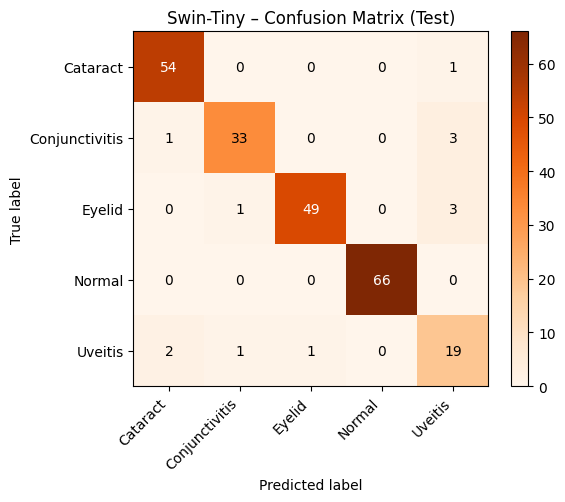

In [ ]:
# Swin-Tiny colourful confusion matrix 

# 1. Rebuilded Swin-Tiny and load best weights
swin_best = create_swin_tiny(len(classes))   # now works
swin_best.load_state_dict(torch.load("best_swin_tiny.pth", map_location=device))
swin_best.to(device)

# 2. to get predictions on test set
y_true_swin, y_pred_swin = get_preds_and_labels(swin_best, test_loader)

# 3. Builded confusion matrix
cm_swin = confusion_matrix(y_true_swin, y_pred_swin)
print("Swin-Tiny Confusion Matrix:")
print(cm_swin)

# 4. Ploted colourful confusion matrix
plot_confusion_matrix(cm_swin, classes, "Swin-Tiny – Confusion Matrix (Test)")



3.DeiT-Tiny

In [ ]:

!pip install timm -q

import timm
import torch
import torch.nn as nn

num_classes = len(classes)

def create_deit_tiny(num_classes: int):
    """
    Build a DeiT-Tiny model (Data-efficient Image Transformer).
    Uses ImageNet pretrained weights and custom classifier head.
    """
    model = timm.create_model(
        "deit_tiny_patch16_224",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.5 
    )
    return model.to(device)

deit_model = create_deit_tiny(num_classes)
deit_model  


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

def train_one_epoch_deit(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss/total, correct/total

def evaluate_deit(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/total, correct/total

# Train DeiT-Tiny 
deit_model = create_deit_tiny(num_classes)
optimizer_deit = optim.AdamW(deit_model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 40
patience   = 5
best_val_loss = float("inf")
wait = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch_deit(deit_model, train_loader, optimizer_deit)
    val_loss,   val_acc   = evaluate_deit(deit_model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(deit_model.state_dict(), "best_deit_tiny.pth")
        print("Saved new best DeiT-Tiny model")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered for DeiT-Tiny")
            break


Epoch 1/40
  Train Loss: 0.7967, Acc: 0.6957
  Val   Loss: 0.4496, Acc: 0.8767
  ✔ Saved new best DeiT-Tiny model
Epoch 2/40
  Train Loss: 0.4017, Acc: 0.8623
  Val   Loss: 0.3248, Acc: 0.9075
  ✔ Saved new best DeiT-Tiny model
Epoch 3/40
  Train Loss: 0.3141, Acc: 0.8906
  Val   Loss: 0.3716, Acc: 0.8943
Epoch 4/40
  Train Loss: 0.2377, Acc: 0.9178
  Val   Loss: 0.2982, Acc: 0.9119
  ✔ Saved new best DeiT-Tiny model
Epoch 5/40
  Train Loss: 0.2264, Acc: 0.9292
  Val   Loss: 0.2830, Acc: 0.8987
  ✔ Saved new best DeiT-Tiny model
Epoch 6/40
  Train Loss: 0.1315, Acc: 0.9592
  Val   Loss: 0.2413, Acc: 0.9295
  ✔ Saved new best DeiT-Tiny model
Epoch 7/40
  Train Loss: 0.1091, Acc: 0.9614
  Val   Loss: 0.1989, Acc: 0.9427
  ✔ Saved new best DeiT-Tiny model
Epoch 8/40
  Train Loss: 0.1426, Acc: 0.9543
  Val   Loss: 0.2367, Acc: 0.9163
Epoch 9/40
  Train Loss: 0.0928, Acc: 0.9717
  Val   Loss: 0.1476, Acc: 0.9604
  ✔ Saved new best DeiT-Tiny model
Epoch 10/40
  Train Loss: 0.0619, Acc: 0.983

DeiT-Tiny Test Accuracy: 0.9359

DeiT-Tiny Classification Report (Test):
                precision    recall  f1-score   support

      Cataract       1.00      0.95      0.97        55
Conjunctivitis       0.92      0.92      0.92        37
        Eyelid       0.94      0.87      0.90        53
        Normal       1.00      0.98      0.99        66
       Uveitis       0.71      0.96      0.81        23

      accuracy                           0.94       234
     macro avg       0.91      0.93      0.92       234
  weighted avg       0.94      0.94      0.94       234


Confusion Matrix (raw counts):
[[52  1  1  0  1]
 [ 0 34  1  0  2]
 [ 0  1 46  0  6]
 [ 0  0  1 65  0]
 [ 0  1  0  0 22]]


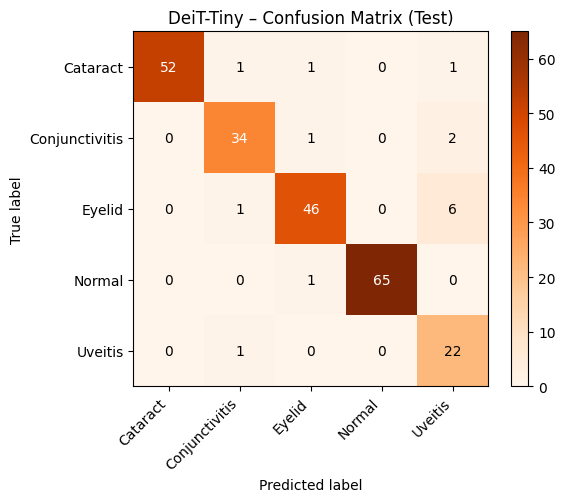

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 1. Reload best DeiT-Tiny
deit_best = create_deit_tiny(num_classes)
deit_best.load_state_dict(torch.load("best_deit_tiny.pth", map_location=device))
deit_best.to(device)
deit_best.eval()

# 2. Get predictions on test set
all_labels, all_preds = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = deit_best(imgs)
        preds = outputs.argmax(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

#  Basic test accuracy 
test_acc = (all_labels == all_preds).mean()
print(f"DeiT-Tiny Test Accuracy: {test_acc:.4f}")

#  Classification report 
print("\nDeiT-Tiny Classification Report (Test):")
print(classification_report(all_labels, all_preds, target_names=classes))

#Confusion matrix 
cm_deit = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix (raw counts):")
print(cm_deit)

# Colorful plot helper
def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest", cmap="Oranges")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_deit, classes, "DeiT-Tiny – Confusion Matrix (Test)")


4.LeVit-256

In [ ]:
#  LeViT-256 model 

!pip install timm -q  

import timm
import torch
import torch.nn as nn


num_classes = len(classes)

def create_levit_256(num_classes: int):
    """
    Build a LeViT-256 transformer model for image classification.
    Uses pretrained weights and replaces final head for your dataset.
    """
    model = timm.create_model(
        "levit_256",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.5   
    )
    return model.to(device)


levit_model = create_levit_256(num_classes)
levit_model


model.safetensors:   0%|          | 0.00/75.9M [00:00<?, ?B/s]

LevitDistilled(
  (stem): Stem16(
    (conv1): ConvNorm(
      (linear): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act1): Hardswish()
    (conv2): ConvNorm(
      (linear): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act2): Hardswish()
    (conv3): ConvNorm(
      (linear): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act3): Hardswish()
    (conv4): ConvNorm(
      (linear): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stages): Sequential(
  

In [ ]:
#  Train LeViT-256 with early stopping 

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

def train_one_epoch_levit(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss/total, correct/total

def evaluate_levit(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/total, correct/total

# fresh LeViT-256 for training
levit_model = create_levit_256(num_classes)
optimizer_levit = optim.AdamW(levit_model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 40
patience   = 7
best_val_loss = float("inf")
wait = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch_levit(levit_model, train_loader, optimizer_levit)
    val_loss,   val_acc   = evaluate_levit(levit_model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(levit_model.state_dict(), "best_levit256.pth")
        print("Saved new best LeViT-256 model")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered for LeViT-256")
            break


Epoch 1/40
  Train Loss: 1.4071, Acc: 0.5427
  Val   Loss: 1.3355, Acc: 0.7004
  ✔ Saved new best LeViT-256 model
Epoch 2/40
  Train Loss: 1.0232, Acc: 0.7278
  Val   Loss: 0.9588, Acc: 0.7489
  ✔ Saved new best LeViT-256 model
Epoch 3/40
  Train Loss: 0.7899, Acc: 0.7567
  Val   Loss: 0.6786, Acc: 0.8018
  ✔ Saved new best LeViT-256 model
Epoch 4/40
  Train Loss: 0.6099, Acc: 0.8073
  Val   Loss: 0.8373, Acc: 0.8458
Epoch 5/40
  Train Loss: 0.5024, Acc: 0.8361
  Val   Loss: 0.4153, Acc: 0.8987
  ✔ Saved new best LeViT-256 model
Epoch 6/40
  Train Loss: 0.3870, Acc: 0.8862
  Val   Loss: 0.3420, Acc: 0.9075
  ✔ Saved new best LeViT-256 model
Epoch 7/40
  Train Loss: 0.3186, Acc: 0.9080
  Val   Loss: 0.2930, Acc: 0.9075
  ✔ Saved new best LeViT-256 model
Epoch 8/40
  Train Loss: 0.2563, Acc: 0.9336
  Val   Loss: 0.2362, Acc: 0.9383
  ✔ Saved new best LeViT-256 model
Epoch 9/40
  Train Loss: 0.2092, Acc: 0.9445
  Val   Loss: 0.2242, Acc: 0.9295
  ✔ Saved new best LeViT-256 model
Epoch 10/

LeViT-256 Test Accuracy: 0.9402

LeViT-256 Classification Report (Test):
                precision    recall  f1-score   support

      Cataract       0.91      0.96      0.94        55
Conjunctivitis       0.87      0.89      0.88        37
        Eyelid       0.96      0.92      0.94        53
        Normal       1.00      1.00      1.00        66
       Uveitis       0.90      0.83      0.86        23

      accuracy                           0.94       234
     macro avg       0.93      0.92      0.92       234
  weighted avg       0.94      0.94      0.94       234


LeViT-256 Confusion Matrix (raw counts):
[[53  0  1  0  1]
 [ 2 33  1  0  1]
 [ 3  1 49  0  0]
 [ 0  0  0 66  0]
 [ 0  4  0  0 19]]


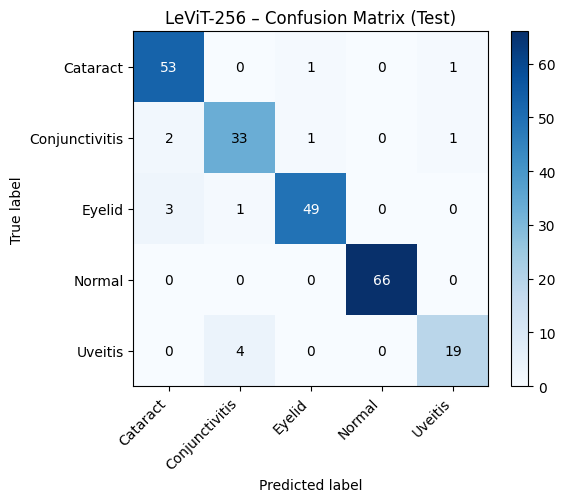

In [ ]:
# Evaluate LeViT-256 on test set 

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

#  helper 
def get_preds_and_labels(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

#  colorful confusion matrix helper 
def plot_confusion_matrix(cm, classes, title, cmap_choice="Blues"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest", cmap=cmap_choice)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

# 1. Reload best LeViT-256
levit_best = create_levit_256(num_classes)
levit_best.load_state_dict(torch.load("best_levit256.pth", map_location=device))
levit_best.to(device)

# 2. Get predictions on test set
y_true_levit, y_pred_levit = get_preds_and_labels(levit_best, test_loader)

# 3. Test accuracy
levit_test_acc = (y_true_levit == y_pred_levit).mean()
print(f"LeViT-256 Test Accuracy: {levit_test_acc:.4f}")

# 4. Classification report
print("\nLeViT-256 Classification Report (Test):")
print(classification_report(y_true_levit, y_pred_levit, target_names=classes))

# 5. Confusion matrix (raw)
cm_levit = confusion_matrix(y_true_levit, y_pred_levit)
print("\nLeViT-256 Confusion Matrix (raw counts):")
print(cm_levit)

# 6. Colorful confusion matrix
plot_confusion_matrix(cm_levit, classes, "LeViT-256 – Confusion Matrix (Test)", cmap_choice="Blues")


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def get_preds_and_labels(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(cm, classes, title, cmap_choice="Blues"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest", cmap=cmap_choice)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


5.ShuffleNetV2

In [ ]:
# ShuffleNetV2 Model Builder

import torch
import torch.nn as nn
from torchvision import models

def create_shufflenet(num_classes):
    """
    ShuffleNetV2 x1.0 pretrained on ImageNet.
    Replace classifier with dropout + linear for 5 classes.
    """
    model = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)

    # Replace classifier head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

# Quick check
shufflenet_model = create_shufflenet(len(classes))
shufflenet_model


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 165MB/s]


ShuffleNetV2(
  (conv1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (stage2): Sequential(
    (0): InvertedResidual(
      (branch1): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_

In [ ]:
# Train ShuffleNetV2

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

def train_one_epoch_shufflenet(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss/total, correct/total


def evaluate_shufflenet(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/total, correct/total


# Actual training loop
shufflenet_model = create_shufflenet(len(classes))
optimizer_shuff = optim.Adam(shufflenet_model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 40
patience   = 5
best_val_loss = float("inf")
wait = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch_shufflenet(shufflenet_model, train_loader, optimizer_shuff)
    val_loss,   val_acc   = evaluate_shufflenet(shufflenet_model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(shufflenet_model.state_dict(), "best_shufflenet.pth")
        print("Saved new best ShuffleNet model")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered")
            break


Epoch 1/40
  Train Loss: 1.5683 | Acc: 0.4780
  Val   Loss: 1.4698 | Acc: 0.5463
  ✔ Saved new best ShuffleNet model
Epoch 2/40
  Train Loss: 1.3614 | Acc: 0.5857
  Val   Loss: 1.1652 | Acc: 0.6432
  ✔ Saved new best ShuffleNet model
Epoch 3/40
  Train Loss: 1.1235 | Acc: 0.7033
  Val   Loss: 0.9581 | Acc: 0.7974
  ✔ Saved new best ShuffleNet model
Epoch 4/40
  Train Loss: 0.8990 | Acc: 0.7801
  Val   Loss: 0.7169 | Acc: 0.8414
  ✔ Saved new best ShuffleNet model
Epoch 5/40
  Train Loss: 0.7025 | Acc: 0.8149
  Val   Loss: 0.5524 | Acc: 0.8502
  ✔ Saved new best ShuffleNet model
Epoch 6/40
  Train Loss: 0.5600 | Acc: 0.8416
  Val   Loss: 0.4468 | Acc: 0.8634
  ✔ Saved new best ShuffleNet model
Epoch 7/40
  Train Loss: 0.4741 | Acc: 0.8519
  Val   Loss: 0.3860 | Acc: 0.8722
  ✔ Saved new best ShuffleNet model
Epoch 8/40
  Train Loss: 0.4039 | Acc: 0.8704
  Val   Loss: 0.3552 | Acc: 0.8722
  ✔ Saved new best ShuffleNet model
Epoch 9/40
  Train Loss: 0.3648 | Acc: 0.8841
  Val   Loss: 0.35

ShuffleNet Test Accuracy: 0.9359

ShuffleNet Classification Report (Test):
                precision    recall  f1-score   support

      Cataract       0.96      0.91      0.93        55
Conjunctivitis       0.83      0.95      0.89        37
        Eyelid       0.96      0.92      0.94        53
        Normal       1.00      1.00      1.00        66
       Uveitis       0.83      0.83      0.83        23

      accuracy                           0.94       234
     macro avg       0.92      0.92      0.92       234
  weighted avg       0.94      0.94      0.94       234


ShuffleNet Confusion Matrix (raw counts):
[[50  3  0  0  2]
 [ 0 35  1  0  1]
 [ 1  2 49  0  1]
 [ 0  0  0 66  0]
 [ 1  2  1  0 19]]


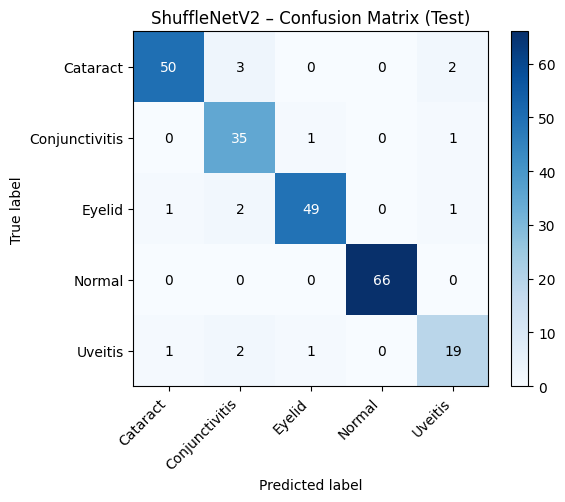

In [ ]:
#Evaluate ShuffleNetV2

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# (Optional) prediction helper — if not already defined
def get_preds_and_labels(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# colorful confusion matrix helper
def plot_confusion_matrix(cm, classes, title, cmap_choice="Blues"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest", cmap=cmap_choice)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


# 1. Load best ShuffleNet model
shuff_best = create_shufflenet(len(classes))
shuff_best.load_state_dict(torch.load("best_shufflenet.pth", map_location=device))
shuff_best.to(device)

# 2. Get predictions
y_true_shuf, y_pred_shuf = get_preds_and_labels(shuff_best, test_loader)

# 3. Accuracy
shuf_test_acc = (y_true_shuf == y_pred_shuf).mean()
print(f"ShuffleNet Test Accuracy: {shuf_test_acc:.4f}")

# 4. Classification report
print("\nShuffleNet Classification Report (Test):")
print(classification_report(y_true_shuf, y_pred_shuf, target_names=classes))

# 5. Confusion matrix
cm_shuf = confusion_matrix(y_true_shuf, y_pred_shuf)
print("\nShuffleNet Confusion Matrix (raw counts):")
print(cm_shuf)

# 6. Colorful plot
plot_confusion_matrix(cm_shuf, classes, "ShuffleNetV2 – Confusion Matrix (Test)", cmap_choice="Blues")


6.MobileViT-XS model

In [ ]:
#MobileViT-XS model

!pip install timm -q  

import timm
import torch
import torch.nn as nn

num_classes = len(classes)

def create_mobilevit_xs(num_classes: int):
    """
    a MobileViT-XS model using timm.
    - Lightweight hybrid CNN + Transformer
    - Pretrained on ImageNet
    - Final head adapted to your number of classes
    """
    model = timm.create_model(
        "mobilevit_xs",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.5
    )
    return model.to(device)

# sanity check
mobilevit_model = create_mobilevit_xs(num_classes)
mobilevit_model


model.safetensors:   0%|          | 0.00/9.34M [00:00<?, ?B/s]

ByobNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (stages): Sequential(
    (0): Sequential(
      (0): BottleneckBlock(
        (conv1_1x1): ConvNormAct(
          (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
        )
        (conv2_kxk): ConvNormAct(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
   

In [ ]:
#Train MobileViT-XS with early stopping

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

def train_one_epoch_mobilevit(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss/total, correct/total


def evaluate_mobilevit(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/total, correct/total


# create fresh MobileViT-XS for training
mobilevit_model = create_mobilevit_xs(num_classes)
optimizer_mobilevit = optim.AdamW(mobilevit_model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs   = 40
patience     = 5
best_val_loss = float("inf")
wait = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch_mobilevit(mobilevit_model, train_loader, optimizer_mobilevit)
    val_loss,   val_acc   = evaluate_mobilevit(mobilevit_model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(mobilevit_model.state_dict(), "best_mobilevit_xs.pth")
        print("Saved new best MobileViT-XS model")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered for MobileViT-XS")
            break


Epoch 1/40
  Train Loss: 1.4783 | Acc: 0.6042
  Val   Loss: 1.3242 | Acc: 0.7269
  ✔ Saved new best MobileViT-XS model
Epoch 2/40
  Train Loss: 1.0598 | Acc: 0.7746
  Val   Loss: 0.7791 | Acc: 0.8194
  ✔ Saved new best MobileViT-XS model
Epoch 3/40
  Train Loss: 0.6970 | Acc: 0.8280
  Val   Loss: 0.5308 | Acc: 0.8458
  ✔ Saved new best MobileViT-XS model
Epoch 4/40
  Train Loss: 0.4881 | Acc: 0.8617
  Val   Loss: 0.4099 | Acc: 0.8722
  ✔ Saved new best MobileViT-XS model
Epoch 5/40
  Train Loss: 0.3911 | Acc: 0.8928
  Val   Loss: 0.3793 | Acc: 0.8767
  ✔ Saved new best MobileViT-XS model
Epoch 6/40
  Train Loss: 0.3346 | Acc: 0.9129
  Val   Loss: 0.3001 | Acc: 0.9251
  ✔ Saved new best MobileViT-XS model
Epoch 7/40
  Train Loss: 0.2769 | Acc: 0.9314
  Val   Loss: 0.3098 | Acc: 0.8899
Epoch 8/40
  Train Loss: 0.2396 | Acc: 0.9379
  Val   Loss: 0.2615 | Acc: 0.9163
  ✔ Saved new best MobileViT-XS model
Epoch 9/40
  Train Loss: 0.1801 | Acc: 0.9586
  Val   Loss: 0.2372 | Acc: 0.9339
  ✔ S

MobileViT-XS Test Accuracy: 0.9573

MobileViT-XS Classification Report (Test):
                precision    recall  f1-score   support

      Cataract       0.96      0.98      0.97        55
Conjunctivitis       0.97      0.92      0.94        37
        Eyelid       0.96      0.96      0.96        53
        Normal       1.00      1.00      1.00        66
       Uveitis       0.79      0.83      0.81        23

      accuracy                           0.96       234
     macro avg       0.94      0.94      0.94       234
  weighted avg       0.96      0.96      0.96       234


MobileViT-XS Confusion Matrix (raw counts):
[[54  0  0  0  1]
 [ 0 34  1  0  2]
 [ 0  0 51  0  2]
 [ 0  0  0 66  0]
 [ 2  1  1  0 19]]


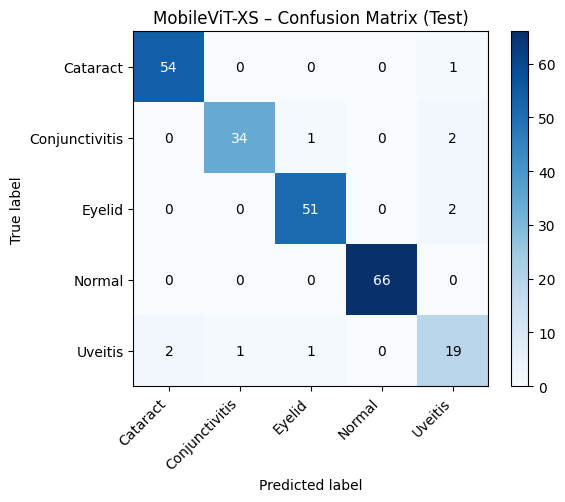

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def get_preds_and_labels(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(cm, classes, title, cmap_choice="Blues"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest", cmap=cmap_choice)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

# Reload best MobileViT model
mobilevit_best = create_mobilevit_xs(num_classes)
mobilevit_best.load_state_dict(torch.load("best_mobilevit_xs.pth", map_location=device))
mobilevit_best.to(device)

# Get predictions
y_true_mvit, y_pred_mvit = get_preds_and_labels(mobilevit_best, test_loader)

# Accuracy
mvit_test_acc = (y_true_mvit == y_pred_mvit).mean()
print(f"MobileViT-XS Test Accuracy: {mvit_test_acc:.4f}")

# Classification report
print("\nMobileViT-XS Classification Report (Test):")
print(classification_report(y_true_mvit, y_pred_mvit, target_names=classes))

# Confusion matrix
cm_mvit = confusion_matrix(y_true_mvit, y_pred_mvit)
print("\nMobileViT-XS Confusion Matrix (raw counts):")
print(cm_mvit)

plot_confusion_matrix(cm_mvit, classes, "MobileViT-XS – Confusion Matrix (Test)")


# ResNet GradCam (GradCam for the Best performing model)

In [35]:
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Rebuild and load your best ResNet18 weights
resnet_best = create_resnet18(len(classes))
resnet_best.load_state_dict(torch.load("best_resnet18.pth", map_location=device))
resnet_best.to(device)
resnet_best.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [36]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # forward hook: save activations
        self.fwd_hook = target_layer.register_forward_hook(self._save_activation)
        # backward hook: save gradients
        self.bwd_hook = target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output is a tuple; we want grad w.r.t. output
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        """
        x: input tensor (1, 3, H, W)
        class_idx: optional target class index; if None, uses model prediction.
        """
        self.model.zero_grad()
        out = self.model(x)  # logits, shape (1, num_classes)

        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        target = out[0, class_idx]
        target.backward()

        # gradients: (1, C, H', W')
        grads = self.gradients  # (1, C, H, W)
        acts = self.activations # (1, C, H, W)

        # global average pool over H,W -> (C,)
        weights = grads.mean(dim=(2, 3))[0]  # (C,)

        # weighted sum of activations
        cam = torch.zeros(acts.shape[2:], dtype=torch.float32).to(x.device)  # (H, W)
        for c, w in enumerate(weights):
            cam += w * acts[0, c, :, :]

        # ReLU
        cam = torch.relu(cam)

        # normalize to [0,1]
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()


In [37]:
target_layer = resnet_best.layer4[-1]
gradcam_resnet = GradCAM(resnet_best, target_layer)


In [38]:
def show_gradcam_on_image(img_path, model_gradcam, transform, true_label=None, title_prefix="ResNet18"):
    # 1. Load & preprocess
    orig = Image.open(img_path).convert("RGB")
    img_t = transform(orig).unsqueeze(0).to(device)  # (1,3,H,W)

    # 2. Get CAM and predicted class
    cam, pred_idx = model_gradcam(img_t)
    pred_class = classes[pred_idx]

    # 3. Resize CAM to image size
    cam_resized = cv2.resize(cam, orig.size)  # (W,H)
    heatmap = plt.cm.jet(cam_resized)[..., :3]  # RGBA -> RGB

    # 4. Overlay heatmap on original
    orig_np = np.array(orig) / 255.0
    overlay = 0.4 * orig_np + 0.6 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # 5. Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(orig)
    plt.axis("off")
    plt.title("Original" if true_label is None else f"Original\nTrue: {true_label}")

    plt.subplot(1,3,2)
    plt.imshow(cam_resized, cmap="jet")
    plt.axis("off")
    plt.title("Grad-CAM Mask")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"{title_prefix}\nPred: {pred_class}")

    plt.tight_layout()
    plt.show()


Image 0: /kaggle/working/eye_splits/test/Cataract/322.png | True: Cataract


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


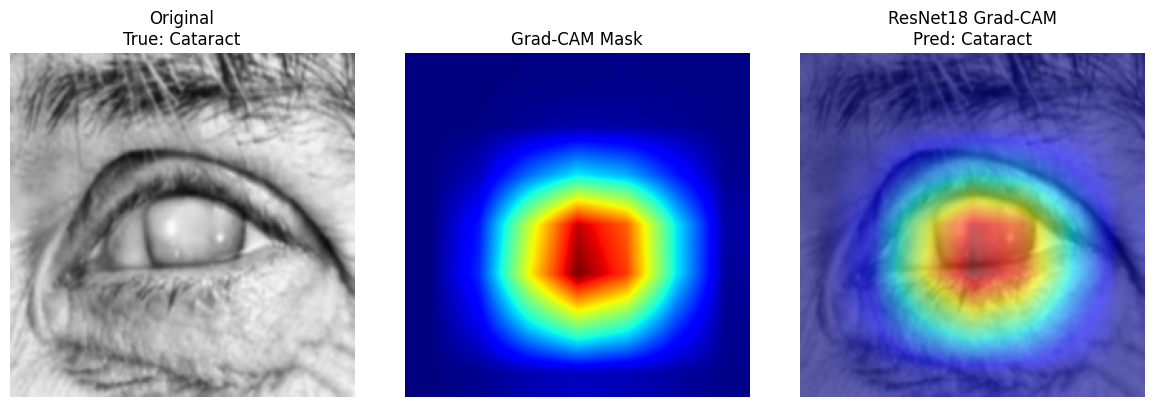

Image 1: /kaggle/working/eye_splits/test/Cataract/aug_788.png | True: Cataract


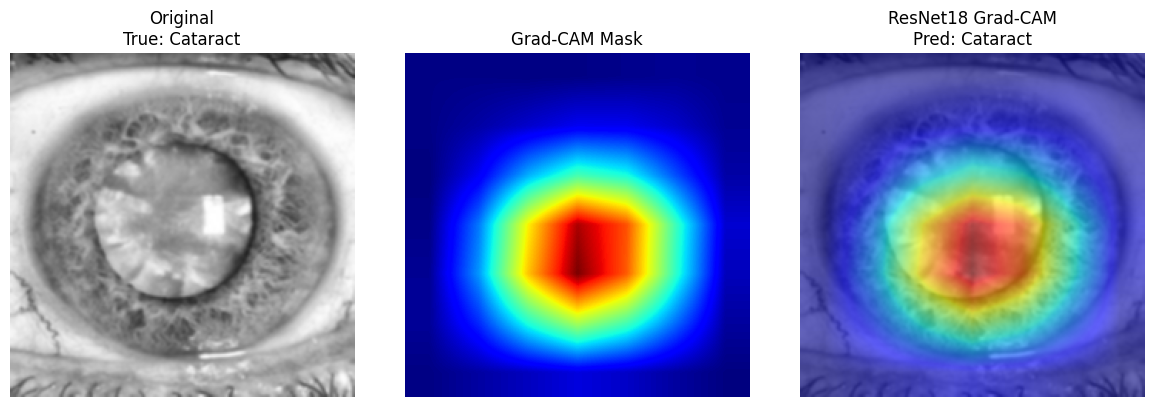

Image 2: /kaggle/working/eye_splits/test/Cataract/aug_911.png | True: Cataract


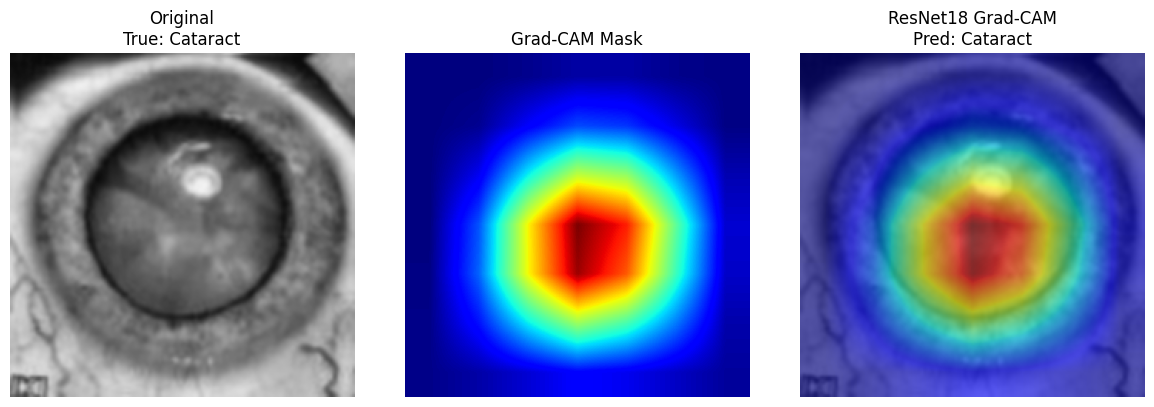

Image 3: /kaggle/working/eye_splits/test/Cataract/aug_966.png | True: Cataract


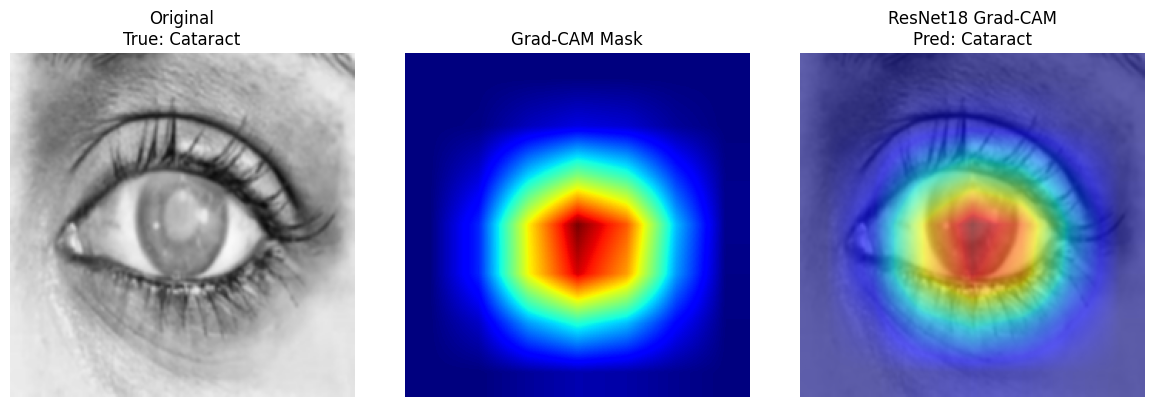

Image 4: /kaggle/working/eye_splits/test/Cataract/296.png | True: Cataract


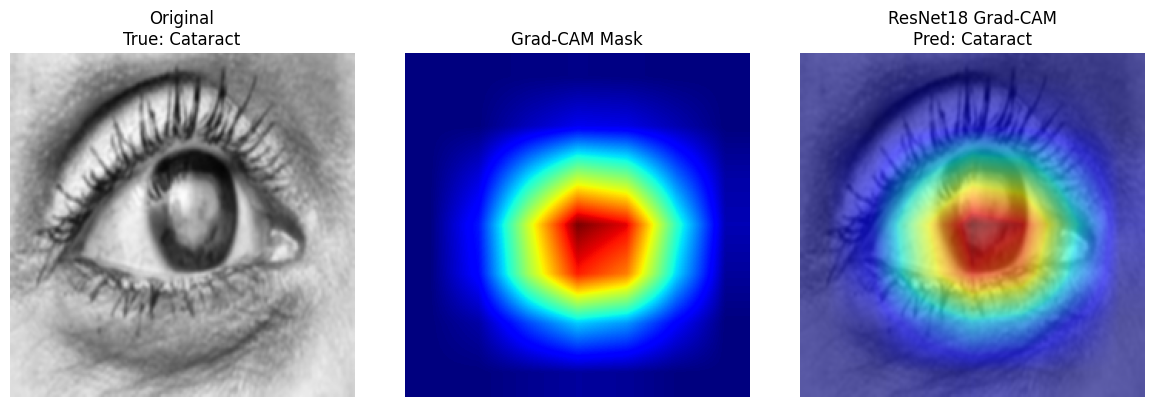

In [39]:
# Example: show Grad-CAM for the first few test images
for i in range(5):
    img_path, label_idx = test_ds.samples[i]
    true_class = classes[label_idx]
    print(f"Image {i}: {img_path} | True: {true_class}")

    show_gradcam_on_image(
        img_path,
        gradcam_resnet,
        test_tf,                 # your test transform
        true_label=true_class,
        title_prefix="ResNet18 Grad-CAM"
    )


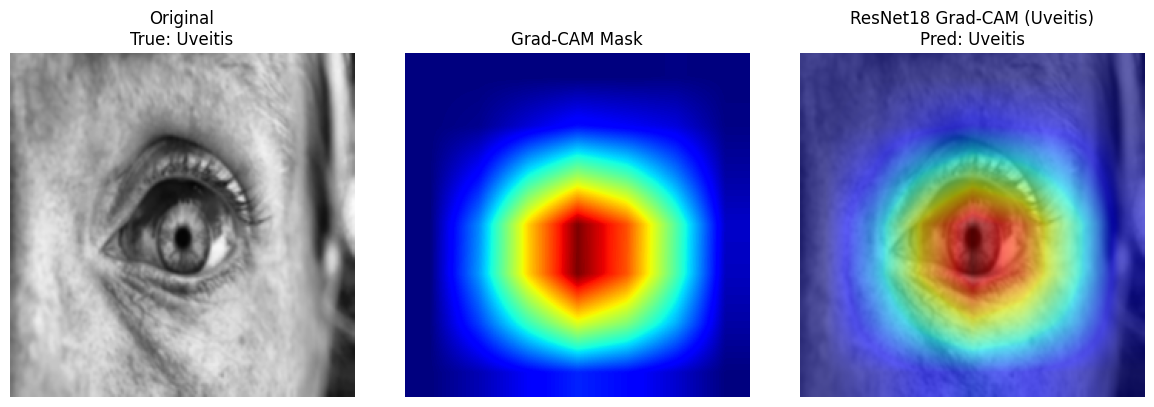

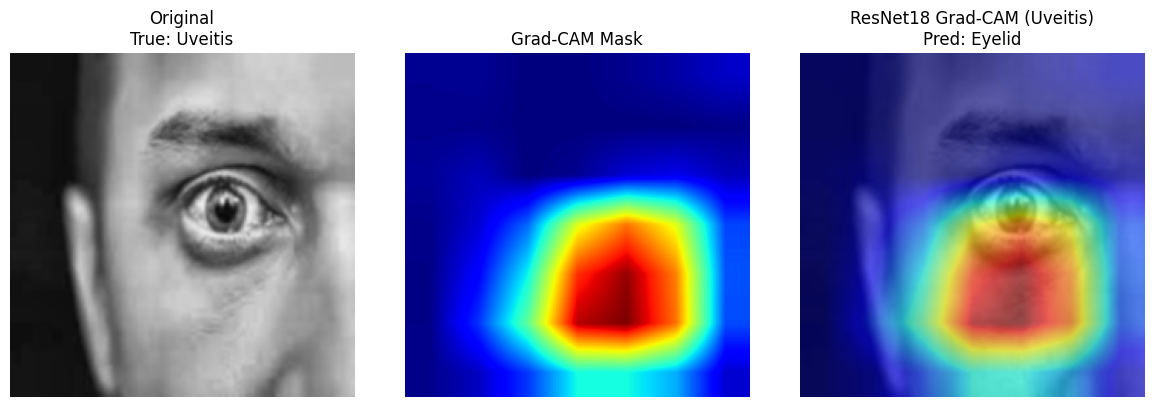

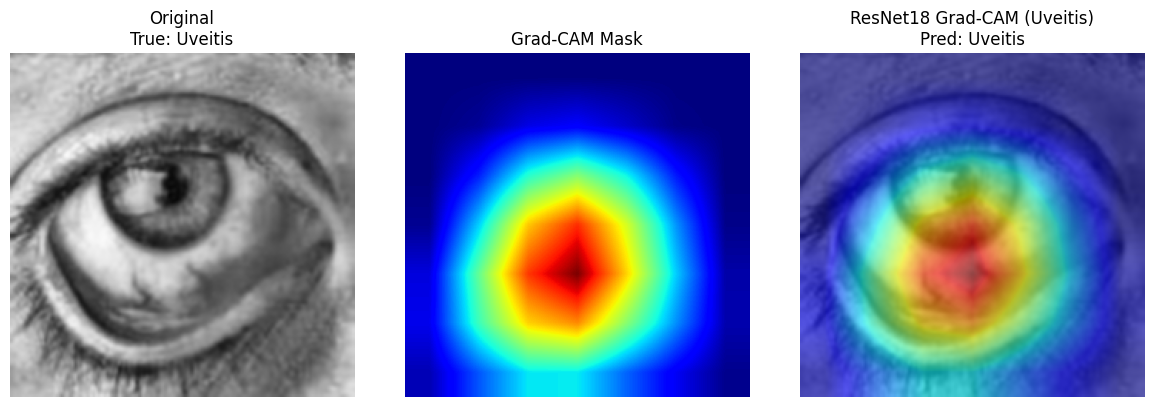

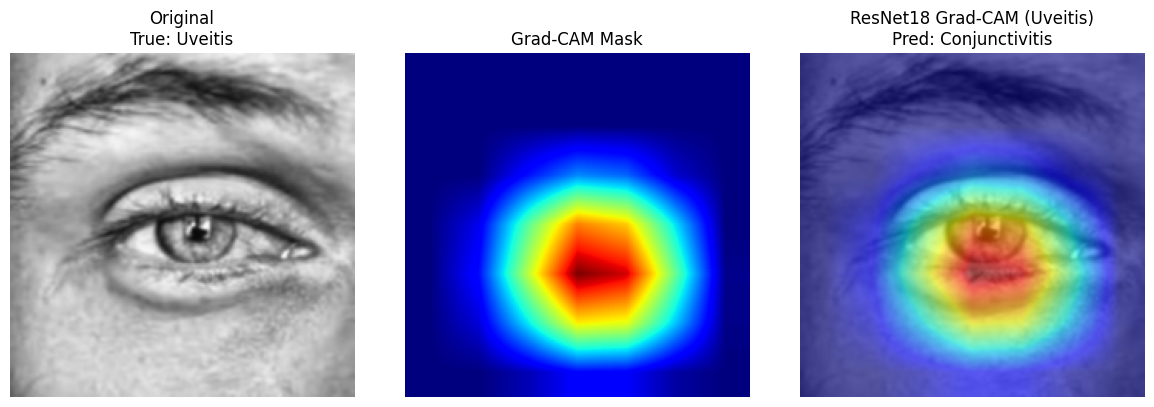

In [40]:
# Show Grad-CAM for some Uveitis images
uveitis_idx = [i for i, (_, lbl) in enumerate(test_ds.samples) if classes[lbl] == "Uveitis"]

for i in uveitis_idx[:4]:
    img_path, label_idx = test_ds.samples[i]
    true_class = classes[label_idx]
    show_gradcam_on_image(
        img_path,
        gradcam_resnet,
        test_tf,
        true_label=true_class,
        title_prefix="ResNet18 Grad-CAM (Uveitis)"
    )


In [ ]:
#loaded multiple trained models, evaluated each one on train, validation, and test sets, and printed their accuracies

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# Helper: evaluate any model on any loader and return accuracy
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return accuracy_score(y_true, y_pred)

#LIST OF MODELS YOU WANT TO INCLUDE 
models_to_evaluate = {
    "ResNet18": ("best_resnet18.pth", create_resnet18),
    "Swin-Tiny": ("best_swin_tiny.pth", create_swin_tiny),
    "DeiT-Tiny": ("best_deit_tiny.pth", create_deit_tiny),
    "LeViT-256": ("best_levit256.pth", create_levit_256),
    "ShuffleNetV2": ("best_shufflenet.pth", create_shufflenet),
    "MobileViT-XS": ("best_mobilevit_xs.pth", create_mobilevit_xs),
}

print("====== MODEL PERFORMANCE SUMMARY ======\n")

for model_name, (weight_path, create_fn) in models_to_evaluate.items():
    print(f"Evaluating {model_name}...")

    # load model
    model = create_fn(len(classes))
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.to(device)

    # compute accuracies
    train_acc = evaluate_model(model, train_loader)
    val_acc   = evaluate_model(model, val_loader)
    test_acc  = evaluate_model(model, test_loader)

    print(f"{model_name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Val   Accuracy: {val_acc:.4f}")
    print(f"  Test  Accuracy: {test_acc:.4f}\n")

print("========================================")


====== MODEL PERFORMANCE SUMMARY ======

Evaluating ResNet18...
ResNet18:
  Train Accuracy: 1.0000
  Val   Accuracy: 0.9604
  Test  Accuracy: 0.9744

Evaluating Swin-Tiny...
Swin-Tiny:
  Train Accuracy: 0.9951
  Val   Accuracy: 0.9559
  Test  Accuracy: 0.9444

Evaluating DeiT-Tiny...
DeiT-Tiny:
  Train Accuracy: 0.9858
  Val   Accuracy: 0.9604
  Test  Accuracy: 0.9359

Evaluating LeViT-256...
LeViT-256:
  Train Accuracy: 0.9989
  Val   Accuracy: 0.9780
  Test  Accuracy: 0.9402

Evaluating ShuffleNetV2...
ShuffleNetV2:
  Train Accuracy: 0.9989
  Val   Accuracy: 0.9648
  Test  Accuracy: 0.9359

Evaluating MobileViT-XS...
MobileViT-XS:
  Train Accuracy: 0.9940
  Val   Accuracy: 0.9648
  Test  Accuracy: 0.9573



# Loads all your trained models
# Recomputes accuracies (Train, Val, Test)
# Stores all results in lists
# Plots beautiful grouped bar charts for comparison

Re-evaluating accuracies for bar chart...

Loading ResNet18 from best_resnet18.pth ...
ResNet18 -> Train: 1.0000, Val: 0.9604, Test: 0.9744

Loading Swin-Tiny from best_swin_tiny.pth ...
Swin-Tiny -> Train: 0.9929, Val: 0.9559, Test: 0.9444

Loading DeiT-Tiny from best_deit_tiny.pth ...
DeiT-Tiny -> Train: 0.9842, Val: 0.9604, Test: 0.9359

Loading LeViT-256 from best_levit256.pth ...
LeViT-256 -> Train: 0.9989, Val: 0.9780, Test: 0.9402

Loading ShuffleNetV2 from best_shufflenet.pth ...
ShuffleNetV2 -> Train: 0.9989, Val: 0.9648, Test: 0.9359

Loading MobileViT-XS from best_mobilevit_xs.pth ...
MobileViT-XS -> Train: 0.9935, Val: 0.9648, Test: 0.9573



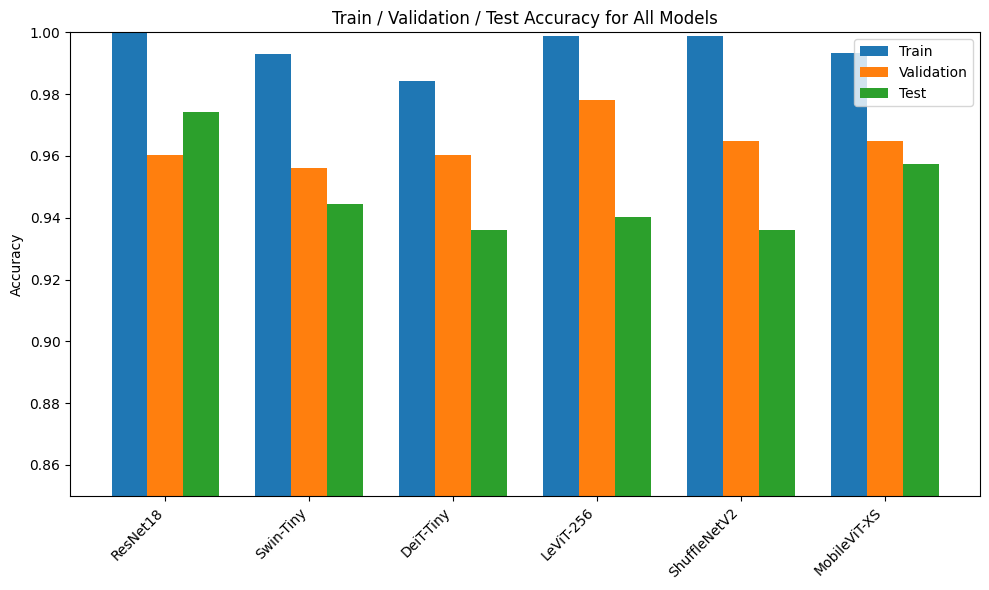

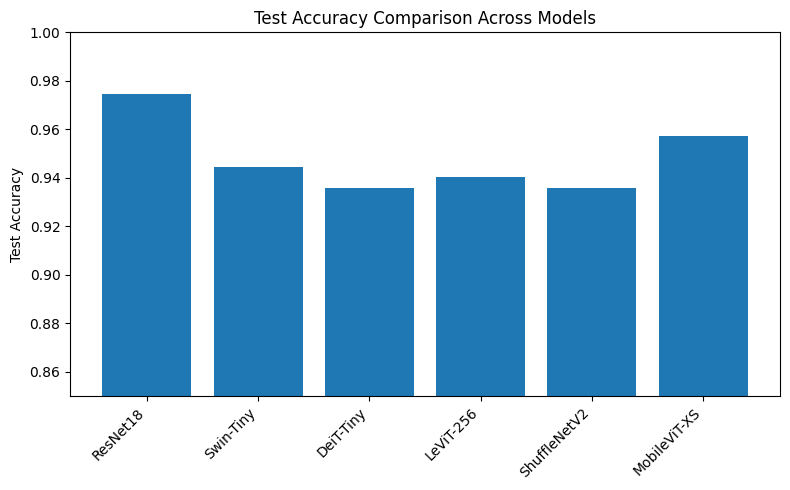

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Helper to evaluate any model on any loader
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return accuracy_score(y_true, y_pred)

# 2. Defined models + weighted paths + created functions
models_to_evaluate = {
    "ResNet18":       ("best_resnet18.pth",        create_resnet18),
    "Swin-Tiny":      ("best_swin_tiny.pth",       create_swin_tiny),
    "DeiT-Tiny":      ("best_deit_tiny.pth",       create_deit_tiny),
    "LeViT-256":      ("best_levit256.pth",        create_levit_256),
    "ShuffleNetV2":   ("best_shufflenet.pth",      create_shufflenet),
    "MobileViT-XS":   ("best_mobilevit_xs.pth",    create_mobilevit_xs),
}

model_names = []
train_accs  = []
val_accs    = []
test_accs   = []

print("Re-evaluating accuracies for bar chart...\n")

# 3. Looped over all models and collect accuracies
for model_name, (weight_path, create_fn) in models_to_evaluate.items():
    print(f"Loading {model_name} from {weight_path} ...")
    model = create_fn(len(classes))
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.to(device)

    tr_acc = evaluate_model(model, train_loader)
    va_acc = evaluate_model(model, val_loader)
    te_acc = evaluate_model(model, test_loader)

    model_names.append(model_name)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)
    test_accs.append(te_acc)

    print(f"{model_name} -> Train: {tr_acc:.4f}, Val: {va_acc:.4f}, Test: {te_acc:.4f}")
    print()

# 4. Ploting grouped bar chart
x = np.arange(len(model_names))
width = 0.25  # width of each bar

plt.figure(figsize=(10,6))
plt.bar(x - width, train_accs, width, label="Train")
plt.bar(x,         val_accs,   width, label="Validation")
plt.bar(x + width, test_accs,  width, label="Test")

plt.xticks(x, model_names, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
plt.title("Train / Validation / Test Accuracy for All Models")
plt.legend()
plt.tight_layout()
plt.show()

# 5.  bar chart only for Test accuracy
plt.figure(figsize=(8,5))
plt.bar(model_names, test_accs)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.ylim(0.85, 1.0)
plt.title("Test Accuracy Comparison Across Models")
plt.tight_layout()
plt.show()



MobileVit-XS Grad-CAM 


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os

# 1. Reload your best MobileViT-XS model
weights_path_mvit = "best_mobilevit_xs.pth"   # change if different path/name

if not os.path.exists(weights_path_mvit):
    print("MobileViT weights not found at:", weights_path_mvit)
else:
    print("Found MobileViT weights at:", weights_path_mvit)

mobilevit_best = create_mobilevit_xs(len(classes))
mobilevit_best.load_state_dict(torch.load(weights_path_mvit, map_location=device))
mobilevit_best.to(device)
mobilevit_best.eval()

# 2. Helper: automatically find the last Conv2d layer (good Grad-CAM target)
def get_last_conv_layer(model):
    last_conv = None
    last_name = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
            last_name = name
    print("Using last Conv2d layer for Grad-CAM:", last_name)
    return last_conv

# 3. Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Hook to store activations
        self.fwd_hook = target_layer.register_forward_hook(self._save_activation)
        # Hook to store gradients
        self.bwd_hook = target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output is a tuple; we want gradient w.r.t. output
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        """
        x: input tensor (1, 3, H, W)
        
        """
        self.model.zero_grad()
        out = self.model(x)  # logits: (1, num_classes)

        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        score = out[0, class_idx]
        score.backward()

        grads = self.gradients      # (1, C, H', W')
        acts  = self.activations    # (1, C, H', W')

        # Average gradients over spatial dimensions -> channel weights
        weights = grads.mean(dim=(2,3))[0]  # (C,)

        # Weighted sum of activations
        cam = torch.zeros(acts.shape[2:], dtype=torch.float32).to(x.device)  # (H', W')
        for c, w in enumerate(weights):
            cam += w * acts[0, c, :, :]

        cam = torch.relu(cam)

        # Normalize to [0,1]
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

# 4. Create Grad-CAM object for MobileViT-XS
target_layer_mvit = get_last_conv_layer(mobilevit_best)
gradcam_mvit = GradCAM(mobilevit_best, target_layer_mvit)


✅ Found MobileViT weights at: best_mobilevit_xs.pth
Using last Conv2d layer for Grad-CAM: final_conv.conv


Image 0: /kaggle/working/eye_splits/test/Cataract/322.png | True: Cataract


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


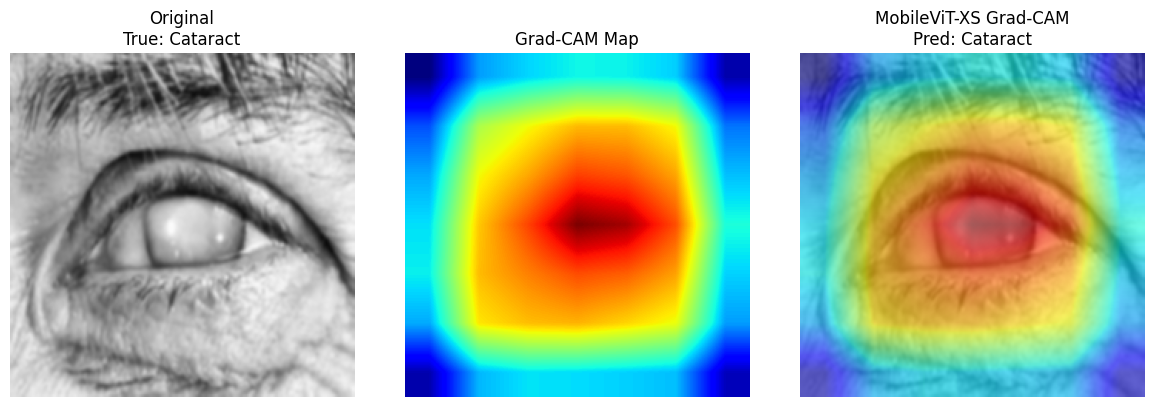

Image 1: /kaggle/working/eye_splits/test/Cataract/aug_788.png | True: Cataract


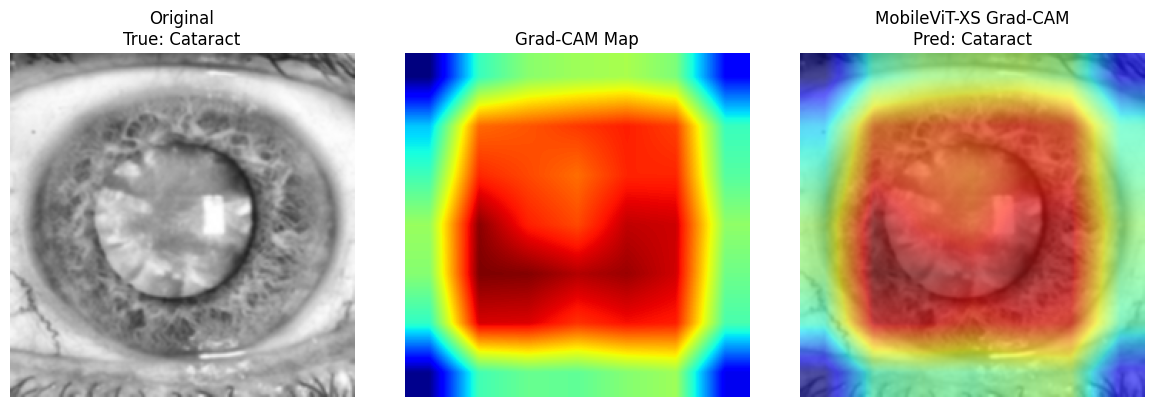

Image 2: /kaggle/working/eye_splits/test/Cataract/aug_911.png | True: Cataract


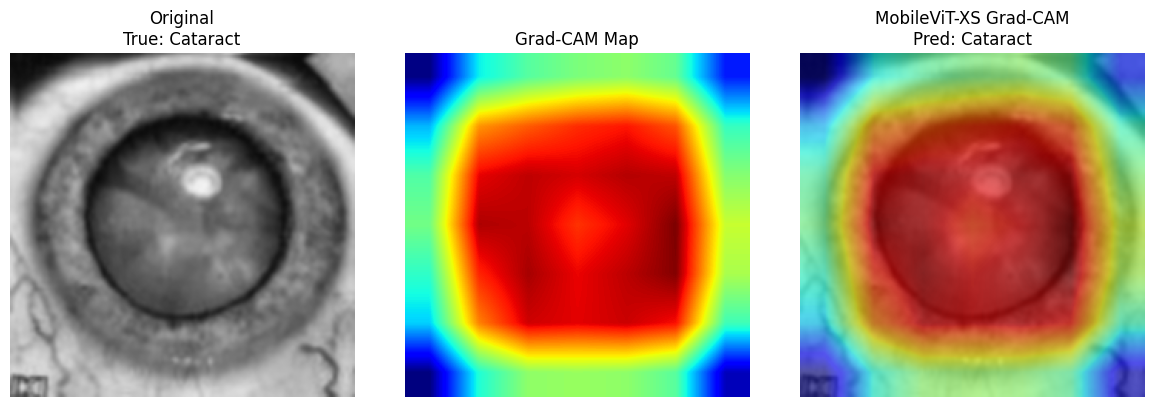


Uveitis indices in test set: [211, 212, 213, 214, 215, 216, 217, 218, 219, 220]


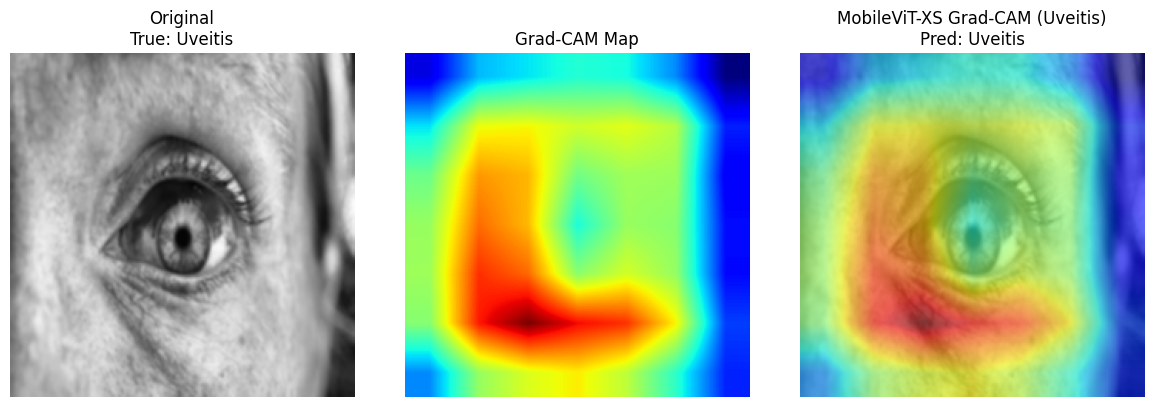

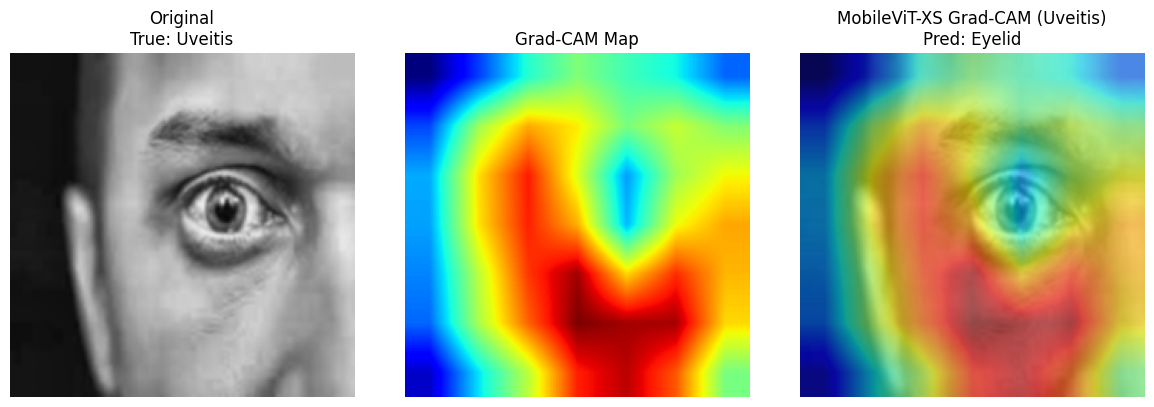

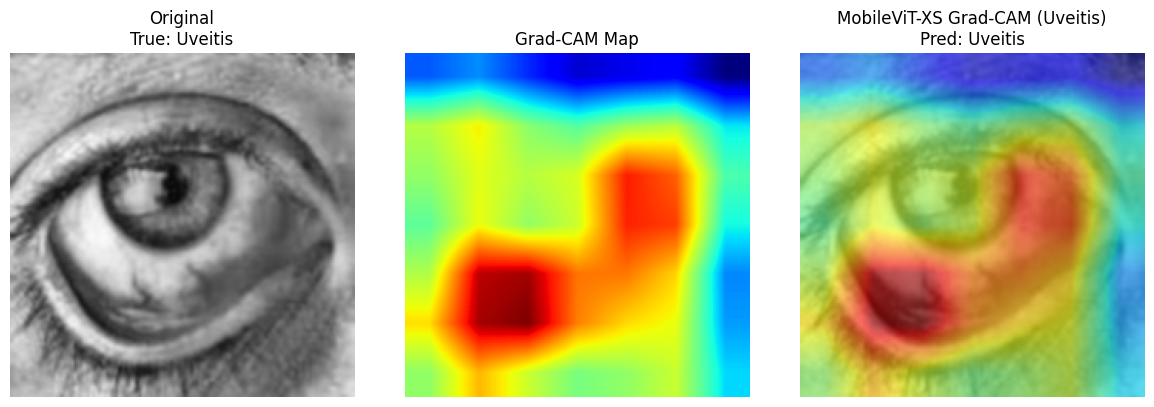

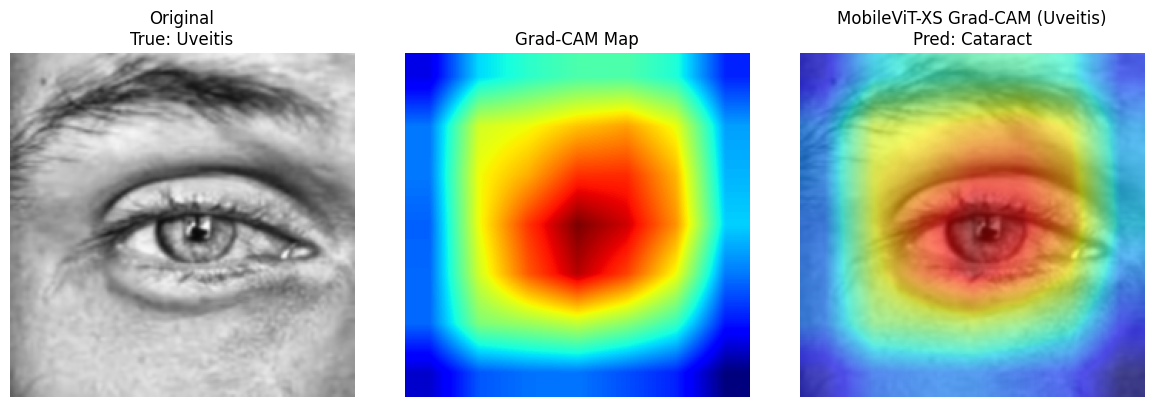

In [50]:
def show_mobilevit_gradcam(img_path, transform, true_label=None, title_prefix="MobileViT-XS"):
    """
    img_path: path to image file
    transform: same transform used for test_loader (e.g., test_tf)
    true_label: optional string class name for display
    """
    # 1. Load & preprocess image
    orig = Image.open(img_path).convert("RGB")
    img_t = transform(orig).unsqueeze(0).to(device)  # (1, 3, H, W)

    # 2. Get CAM & predicted class
    cam, pred_idx = gradcam_mvit(img_t)
    pred_class = classes[pred_idx]

    # 3. Resize CAM to original image size
    cam_resized = cv2.resize(cam, orig.size)  # (W, H)
    heatmap = plt.cm.jet(cam_resized)[..., :3]  # RGBA -> RGB

    # 4. Create overlay
    orig_np = np.array(orig) / 255.0
    overlay = 0.4 * orig_np + 0.6 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # 5. Plot
    plt.figure(figsize=(12,4))

    # Original
    plt.subplot(1,3,1)
    plt.imshow(orig_np)
    plt.axis("off")
    if true_label is None:
        plt.title("Original")
    else:
        plt.title(f"Original\nTrue: {true_label}")

    # CAM
    plt.subplot(1,3,2)
    plt.imshow(cam_resized, cmap="jet")
    plt.axis("off")
    plt.title("Grad-CAM Map")

    # Overlay
    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"{title_prefix}\nPred: {pred_class}")

    plt.tight_layout()
    plt.show()

# ===== Example 1: first 3 test images =====
for i in range(3):
    img_path, label_idx = test_ds.samples[i]  # assumes test_ds.samples = (path, label)
    true_cls = classes[label_idx]
    print(f"Image {i}: {img_path} | True: {true_cls}")

    show_mobilevit_gradcam(
        img_path,
        test_tf,                       # your test transform
        true_label=true_cls,
        title_prefix="MobileViT-XS Grad-CAM"
    )

# ===== Example 2: a few Uveitis images specifically =====
uveitis_idx = [i for i, (_, lbl) in enumerate(test_ds.samples) if classes[lbl] == "Uveitis"]

print("\nUveitis indices in test set:", uveitis_idx[:10])

for i in uveitis_idx[:4]:
    img_path, label_idx = test_ds.samples[i]
    true_cls = classes[label_idx]
    show_mobilevit_gradcam(
        img_path,
        test_tf,
        true_label=true_cls,
        title_prefix="MobileViT-XS Grad-CAM (Uveitis)"
    )


# Compute Advance Metrices

 Per-class medical metrics (Sensitivity, Specificity, PPV, NPV)
 Bootstrapped Confidence Interval for Accuracy
 McNemar Test to compare two models statistically

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1) Per-class metrics from confusion matrix
def compute_per_class_metrics(y_true, y_pred, class_names):
    """
    Returns dict:
      metrics[class_name] = {
        "Sensitivity": ...,
        "Specificity": ...,
        "PPV": ...,
        "NPV": ...
      }
    plus the confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    metrics = {}

    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        sensitivity = TP / (TP + FN + 1e-8)  # recall
        specificity = TN / (TN + FP + 1e-8)
        ppv        = TP / (TP + FP + 1e-8)  # precision
        npv        = TN / (TN + FN + 1e-8)

        metrics[cls] = {
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "PPV": ppv,
            "NPV": npv
        }

    return metrics, cm

# 2) Bootstrap accuracy CI
def bootstrap_accuracy_ci(y_true, y_pred, B=2000, confidence=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    accs = []

    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        acc = (y_true[idx] == y_pred[idx]).mean()
        accs.append(acc)

    accs = np.array(accs)
    lower = np.percentile(accs, (1-confidence)/2 * 100)
    upper = np.percentile(accs, (1+confidence)/2 * 100)
    return lower, upper

# 3) McNemar test between two models
!pip install statsmodels -q
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test_models(y_true, pred1, pred2, name1="Model A", name2="Model B"):
    """
    Compare two models on the SAME test set.
    """
    b = 0  # pred1 wrong, pred2 right
    c = 0  # pred1 right, pred2 wrong

    for yt, p1, p2 in zip(y_true, pred1, pred2):
        if p1 != yt and p2 == yt:
            b += 1
        elif p1 == yt and p2 != yt:
            c += 1

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=True)
    print(f"McNemar test: {name1} vs {name2}")
    print("  b (A wrong, B right):", b)
    print("  c (A right, B wrong):", c)
    print("  p-value:", result.pvalue)

    if result.pvalue < 0.05:
        print("Difference is statistically significant (p < 0.05)\n")
    else:
        print("Difference is NOT statistically significant (p ≥ 0.05)\n")


In [53]:
advanced_rows = []

for model_name, info in summary.items():
    print("="*60)
    print(f"🔹 {model_name} — Advanced Metrics on Test Set")
    print("="*60)

    y_true = info["y_true_test"]
    y_pred = info["y_pred_test"]
    test_acc = info["test_acc"]

    # 1) Per-class metrics + confusion matrix
    per_class_metrics, cm = compute_per_class_metrics(y_true, y_pred, classes)

    print("Confusion Matrix:\n", cm, "\n")

    for cls, vals in per_class_metrics.items():
        print(f"  Class: {cls}")
        print(f"    Sensitivity (Recall): {vals['Sensitivity']:.4f}")
        print(f"    Specificity:          {vals['Specificity']:.4f}")
        print(f"    PPV (Precision):      {vals['PPV']:.4f}")
        print(f"    NPV:                  {vals['NPV']:.4f}")
        print()

    # 2) Macro averages across all classes
    sens_list = [v["Sensitivity"] for v in per_class_metrics.values()]
    spec_list = [v["Specificity"] for v in per_class_metrics.values()]
    ppv_list  = [v["PPV"]        for v in per_class_metrics.values()]
    npv_list  = [v["NPV"]        for v in per_class_metrics.values()]

    mean_sens = np.mean(sens_list)
    mean_spec = np.mean(spec_list)
    mean_ppv  = np.mean(ppv_list)
    mean_npv  = np.mean(npv_list)

    # 3) Bootstrap CI for accuracy
    ci_low, ci_high = bootstrap_accuracy_ci(y_true, y_pred, B=2000, confidence=0.95)

    print(f"Overall Test Accuracy: {test_acc:.4f}")
    print(f"Bootstrap 95% CI for Accuracy: [{ci_low:.4f}, {ci_high:.4f}]\n")
    print(f"Macro Sensitivity: {mean_sens:.4f}")
    print(f"Macro Specificity: {mean_spec:.4f}")
    print(f"Macro PPV:         {mean_ppv:.4f}")
    print(f"Macro NPV:         {mean_npv:.4f}")
    print()

    # Save row for summary table
    advanced_rows.append({
        "Model": model_name,
        "Test_Acc": test_acc,
        "Acc_CI_95_low": ci_low,
        "Acc_CI_95_high": ci_high,
        "Macro_Sensitivity": mean_sens,
        "Macro_Specificity": mean_spec,
        "Macro_PPV": mean_ppv,
        "Macro_NPV": mean_npv
    })

# Build a DataFrame summary for all models
df_advanced = pd.DataFrame(advanced_rows).sort_values("Test_Acc", ascending=False).reset_index(drop=True)
df_advanced


🔹 ResNet18 — Advanced Metrics on Test Set
Confusion Matrix:
 [[55  0  0  0  0]
 [ 0 36  1  0  0]
 [ 0  0 53  0  0]
 [ 0  0  0 66  0]
 [ 1  3  1  0 18]] 

  Class: Cataract
    Sensitivity (Recall): 1.0000
    Specificity:          0.9944
    PPV (Precision):      0.9821
    NPV:                  1.0000

  Class: Conjunctivitis
    Sensitivity (Recall): 0.9730
    Specificity:          0.9848
    PPV (Precision):      0.9231
    NPV:                  0.9949

  Class: Eyelid
    Sensitivity (Recall): 1.0000
    Specificity:          0.9890
    PPV (Precision):      0.9636
    NPV:                  1.0000

  Class: Normal
    Sensitivity (Recall): 1.0000
    Specificity:          1.0000
    PPV (Precision):      1.0000
    NPV:                  1.0000

  Class: Uveitis
    Sensitivity (Recall): 0.7826
    Specificity:          1.0000
    PPV (Precision):      1.0000
    NPV:                  0.9769

Overall Test Accuracy: 0.9744
Bootstrap 95% CI for Accuracy: [0.9530, 0.9915]

Macro Sensi

,Model,Test_Acc,Acc_CI_95_low,Acc_CI_95_high,Macro_Sensitivity,Macro_Specificity,Macro_PPV,Macro_NPV
0,ResNet18,0.974359,0.952991,0.991453,0.951116,0.993627,0.973771,0.994345
1,MobileViT-XS,0.957265,0.931624,0.982906,0.937818,0.989801,0.937929,0.989842
2,Swin-Tiny,0.944444,0.914530,0.974359,0.924865,0.986878,0.920199,0.986656
3,LeViT-256,0.940171,0.910256,0.970085,0.921229,0.985232,0.929552,0.985518
4,DeiT-Tiny,0.935897,0.905983,0.965812,0.934734,0.985109,0.913474,0.983921
5,ShuffleNetV2,0.935897,0.905983,0.965812,0.921130,0.984657,0.916349,0.984259


In [55]:
df_advanced.to_csv("advanced_metrics_all_models.csv", index=False)


McNemar Test on paired models

In [ ]:
!pip install statsmodels -q

import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test_models(y_true, pred1, pred2, name1="Model A", name2="Model B"):
    """
    y_true : ground-truth labels (1D numpy array)
    pred1  : predictions of model 1 (1D numpy array)
    pred2  : predictions of model 2 (1D numpy array)
    """
    b = 0  # model1 wrong, model2 right
    c = 0  # model1 right, model2 wrong

    for yt, p1, p2 in zip(y_true, pred1, pred2):
        if p1 != yt and p2 == yt:
            b += 1
        elif p1 == yt and p2 != yt:
            c += 1

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=True)

    print(f"McNemar test: {name1} vs {name2}")
    print("  b (A wrong, B right):", b)
    print("  c (A right, B wrong):", c)
    print("  p-value:", result.pvalue)

    if result.pvalue < 0.05:
        print("Difference is statistically significant (p < 0.05)\n")
    else:
        print("Difference is NOT statistically significant (p ≥ 0.05)\n")


ResNet18 vs MobileViT-XS

In [57]:
# Get test labels & predictions from summary
res = summary["ResNet18"]
mvit = summary["MobileViT-XS"]

y_true      = res["y_true_test"]          # same ground truth for both
y_pred_res  = res["y_pred_test"]          # ResNet18 predictions
y_pred_mvit = mvit["y_pred_test"]         # MobileViT-XS predictions

# Run McNemar test
mcnemar_test_models(
    y_true,
    y_pred_res,
    y_pred_mvit,
    name1="ResNet18",
    name2="MobileViT-XS"
)


McNemar test: ResNet18 vs MobileViT-XS
  b (A wrong, B right): 2
  c (A right, B wrong): 6
  p-value: 0.2890625
  ✔ Difference is NOT statistically significant (p ≥ 0.05)



In [58]:
# Swin-Tiny vs MobileViT-XS McNemar test

swin = summary["Swin-Tiny"]
mvit = summary["MobileViT-XS"]

# Ground truth (same for both models)
y_true = swin["y_true_test"]

# Predictions
y_pred_swin = swin["y_pred_test"]
y_pred_mvit = mvit["y_pred_test"]

# Run McNemar test
mcnemar_test_models(
    y_true,
    y_pred_swin,
    y_pred_mvit,
    name1="Swin-Tiny",
    name2="MobileViT-XS"
)


McNemar test: Swin-Tiny vs MobileViT-XS
  b (A wrong, B right): 9
  c (A right, B wrong): 6
  p-value: 0.6072387695312499
  ✔ Difference is NOT statistically significant (p ≥ 0.05)



In [59]:
# LeViT-256 vs ShuffleNetV2 McNemar test

lev = summary["LeViT-256"]
shuf = summary["ShuffleNetV2"]

# Ground truth (same for both models)
y_true = lev["y_true_test"]

# Predictions
y_pred_lev  = lev["y_pred_test"]
y_pred_shuf = shuf["y_pred_test"]

# Run McNemar test
mcnemar_test_models(
    y_true,
    y_pred_lev,
    y_pred_shuf,
    name1="LeViT-256",
    name2="ShuffleNetV2"
)


McNemar test: LeViT-256 vs ShuffleNetV2
  b (A wrong, B right): 7
  c (A right, B wrong): 8
  p-value: 1.0
  ✔ Difference is NOT statistically significant (p ≥ 0.05)



In [61]:
#ResNet18 vs ShuffleNetV2
res = summary["ResNet18"]
shuf = summary["ShuffleNetV2"]

y_true = res["y_true_test"]
y_pred_res  = res["y_pred_test"]
y_pred_shuf = shuf["y_pred_test"]

mcnemar_test_models(
    y_true,
    y_pred_res,
    y_pred_shuf,
    name1="ResNet18",
    name2="ShuffleNetV2"
)


McNemar test: ResNet18 vs ShuffleNetV2
  b (A wrong, B right): 2
  c (A right, B wrong): 11
  p-value: 0.0224609375
  ❗ Difference is statistically significant (p < 0.05)



# Full working 5-Fold training structure on ResNet18

In [63]:
# Five-fold cross validation
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score


In [64]:
classes = ["Cataract", "Conjunctivitis", "Eyelid", "Normal", "Uveitis"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FullEyeDataset(Dataset):
    def __init__(self, root, transform):
        self.root = root
        self.transform = transform
        self.samples = []
        self.class_to_idx = {c:i for i,c in enumerate(classes)}

        for cls in classes:
            cls_folder = os.path.join(root, cls)
            for f in os.listdir(cls_folder):
                self.samples.append((os.path.join(cls_folder, f), self.class_to_idx[cls]))

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

    def __len__(self):
        return len(self.samples)


In [65]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [67]:
FULL_DIR = "/kaggle/input/eye-raw"
full_dataset = FullEyeDataset(FULL_DIR, test_tf)

print("Total images:", len(full_dataset))


Total images: 2298


In [68]:
def create_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)


In [70]:
def train_one_fold(train_loader, val_loader, num_epochs=10):
    model = create_resnet18(len(classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    for epoch in range(num_epochs):
        model.train()
        total, correct, loss_sum = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        val_total, val_correct = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f"Epoch {epoch+1}/{num_epochs} — Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return model


In [ ]:
indices = np.arange(len(full_dataset))



🟦 FOLD 1 / 5
Epoch 1/10 — Train Acc: 0.7731 | Val Acc: 0.9261
Epoch 2/10 — Train Acc: 0.9690 | Val Acc: 0.9435
Epoch 3/10 — Train Acc: 0.9924 | Val Acc: 0.9739
Epoch 4/10 — Train Acc: 0.9984 | Val Acc: 0.9652
Epoch 5/10 — Train Acc: 0.9978 | Val Acc: 0.9739
Epoch 6/10 — Train Acc: 0.9995 | Val Acc: 0.9761
Epoch 7/10 — Train Acc: 0.9989 | Val Acc: 0.9696
Epoch 8/10 — Train Acc: 0.9989 | Val Acc: 0.9674
Epoch 9/10 — Train Acc: 0.9989 | Val Acc: 0.9587
Epoch 10/10 — Train Acc: 0.9995 | Val Acc: 0.9696
✔ Fold 1 Accuracy: 0.9696

🟦 FOLD 2 / 5
Epoch 1/10 — Train Acc: 0.8090 | Val Acc: 0.9304
Epoch 2/10 — Train Acc: 0.9755 | Val Acc: 0.9522
Epoch 3/10 — Train Acc: 0.9918 | Val Acc: 0.9652
Epoch 4/10 — Train Acc: 0.9951 | Val Acc: 0.9630
Epoch 5/10 — Train Acc: 0.9978 | Val Acc: 0.9674
Epoch 6/10 — Train Acc: 0.9995 | Val Acc: 0.9609
Epoch 7/10 — Train Acc: 0.9995 | Val Acc: 0.9630
Epoch 8/10 — Train Acc: 1.0000 | Val Acc: 0.9609
Epoch 9/10 — Train Acc: 1.0000 | Val Acc: 0.9630
Epoch 10/10 — 

In [72]:
print("\n==============================")
print("5-Fold Cross-Validation Results")
print("==============================")

for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1}: {acc:.4f}")

print("------------------------------")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Std Deviation: {np.std(fold_accuracies):.4f}")



5-Fold Cross-Validation Results
Fold 1: 0.9696
Fold 2: 0.9652
Fold 3: 0.9652
Fold 4: 0.9673
Fold 5: 0.9739
------------------------------
Mean Accuracy: 0.9682
Std Deviation: 0.0032
